# CNN Fundamentals & Multi-class Classification

:::{Attention}

- Claude was used to help generateing the schematic figures.
- The audiences are welcome to have a deep dive using the book [here](https://d2l.ai/index.html), which is also the material the current notebook refers to.
:::

## 1. Convolutional Neural Network - Reduction on the number of required parameters compared to Fully connected neural network

What is a convolution: $[\mathbf{H}]_{i, j}=u+\sum_a \sum_b[\mathbf{V}]_{a, b}[\mathbf{X}]_{i+a, j+b}$

$[\mathbf{X}]_{i, j}$ and $[\mathbf{H}]_{i, j}$ denote the pixel at location $(i, j)$ in the input image and hidden representation, respectively. $a$ and $b$ denote offset. 

:::{note}

The weight tensor (kernel) $\mathbf{V}$ does not show ${i, j}$ dependence, which indicates that it does not depend on the location within the image, which is what we will talk about in the following: translation invariance.
:::

### 1.1 Translation invariance

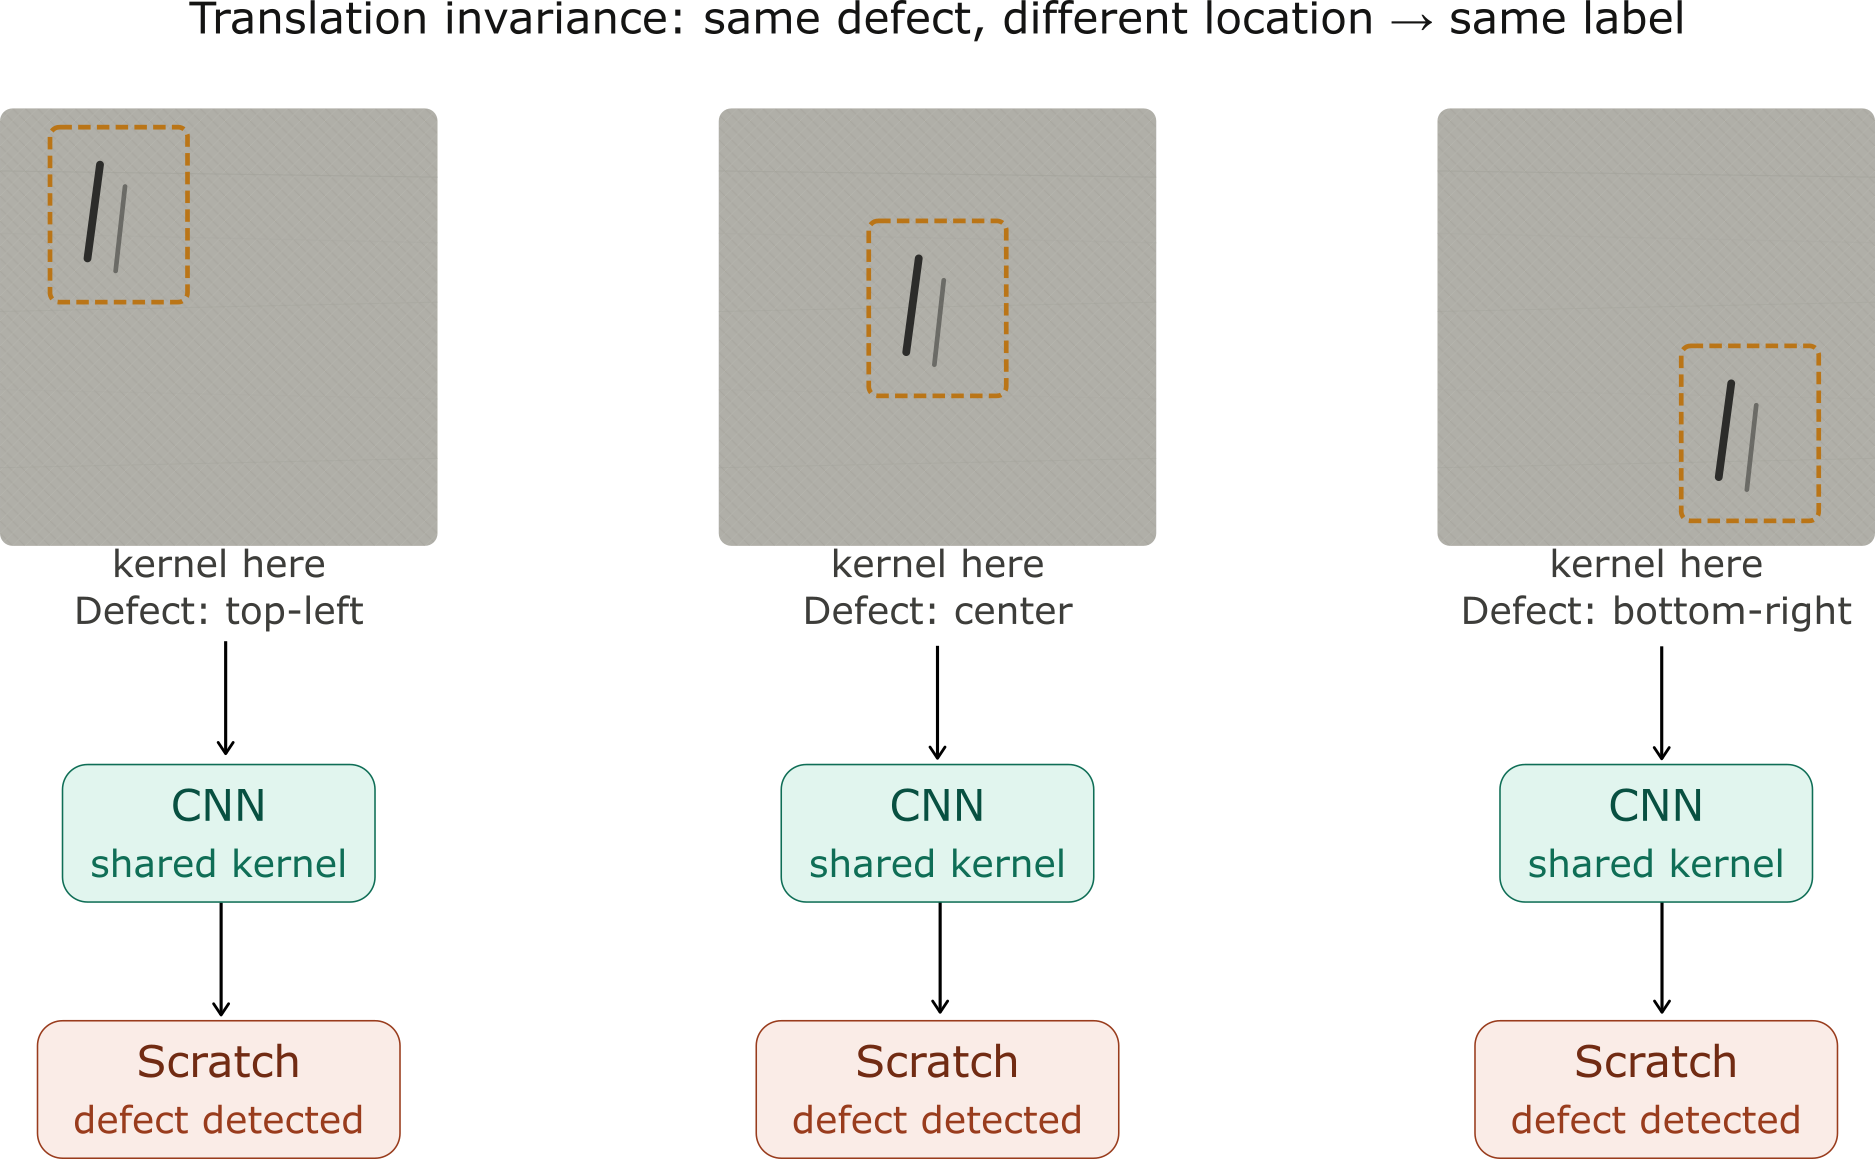

In [1]:
from IPython.display import HTML, display, Image
display(Image('./Fig/02_cnn_translation_invariance_steels.png', width=600))

- Where the defect locates does not affect the consequence whether it will be classified as a defect or what type of defect it is.
- Fully connected neural network vs. CNN

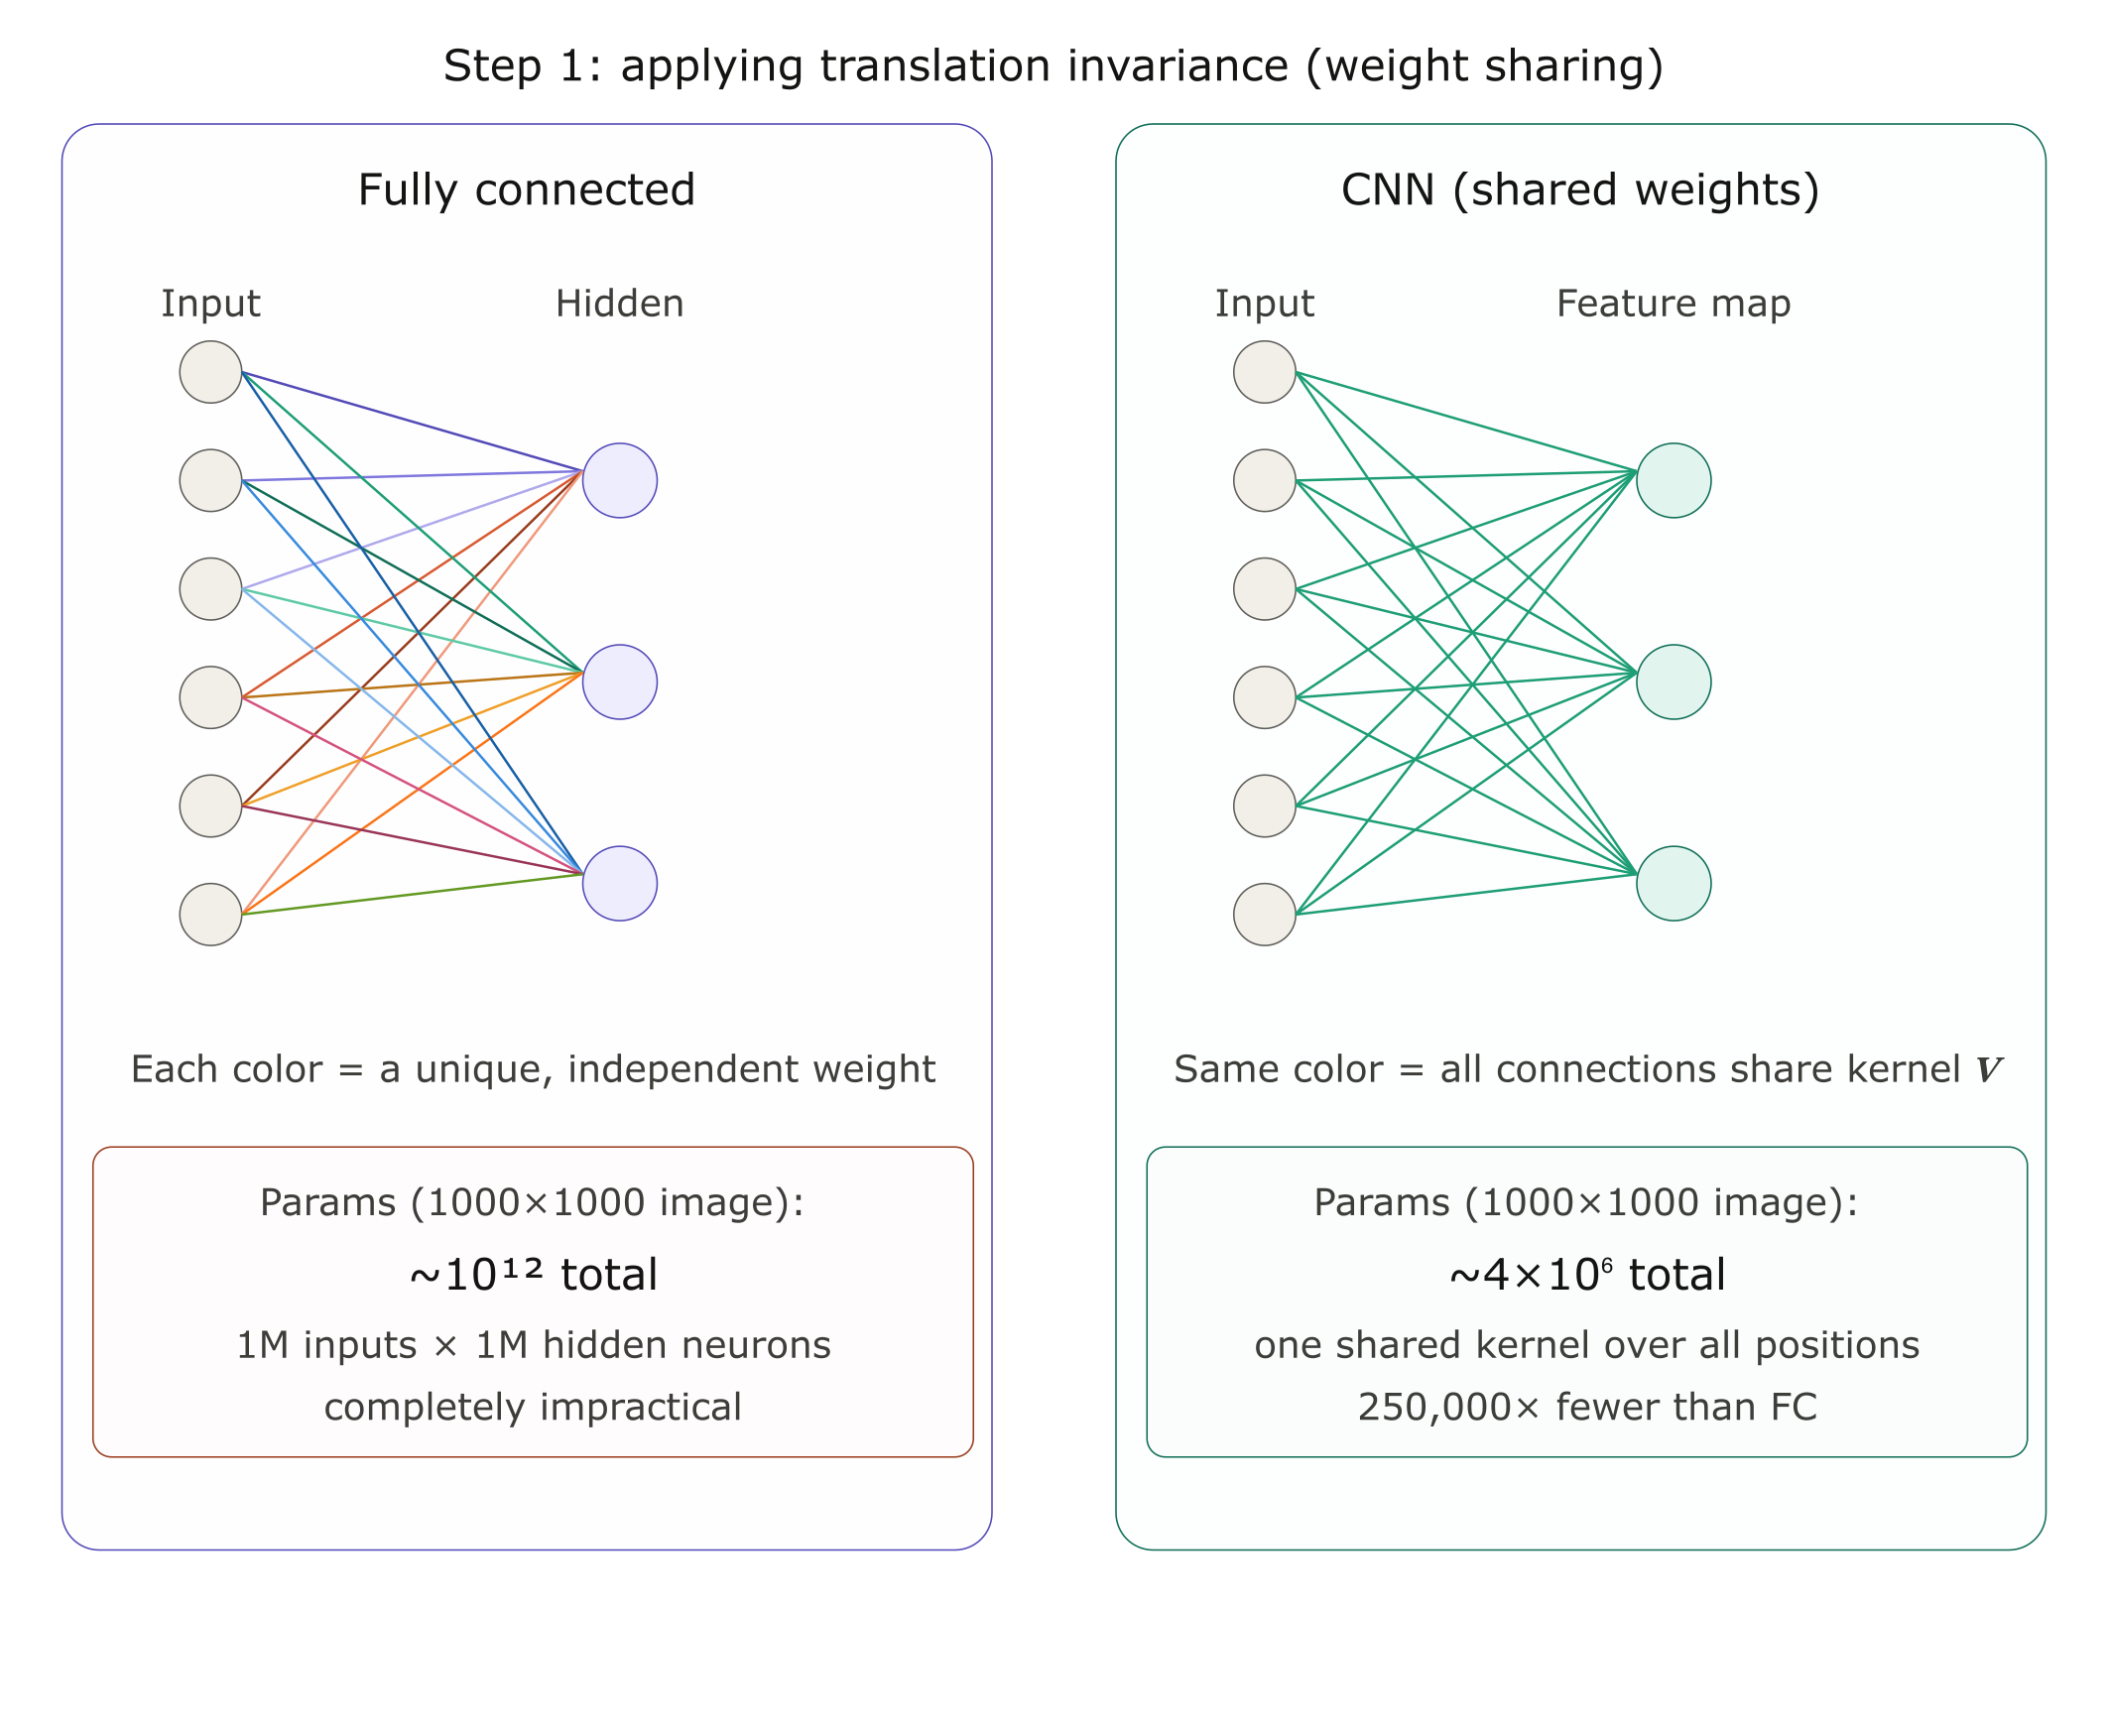

In [2]:
display(Image('./Fig/02_fig1_fc_vs_cnn_shared_weights.png', width=600))


In this example, $a, b \in(-1000,1000)$. However, in practice, one does not have to look very far from the location ${i, j}$ in order to gather information to assess what is going on with $[\mathbf{H}]_{i, j}$. In other words, we can define $a, b \in(-\Delta,\Delta)$. Consequently, the number of parameters can be further reduced. 

This brings up to introduced the second important concept in CNN:

### 1.2 Locality

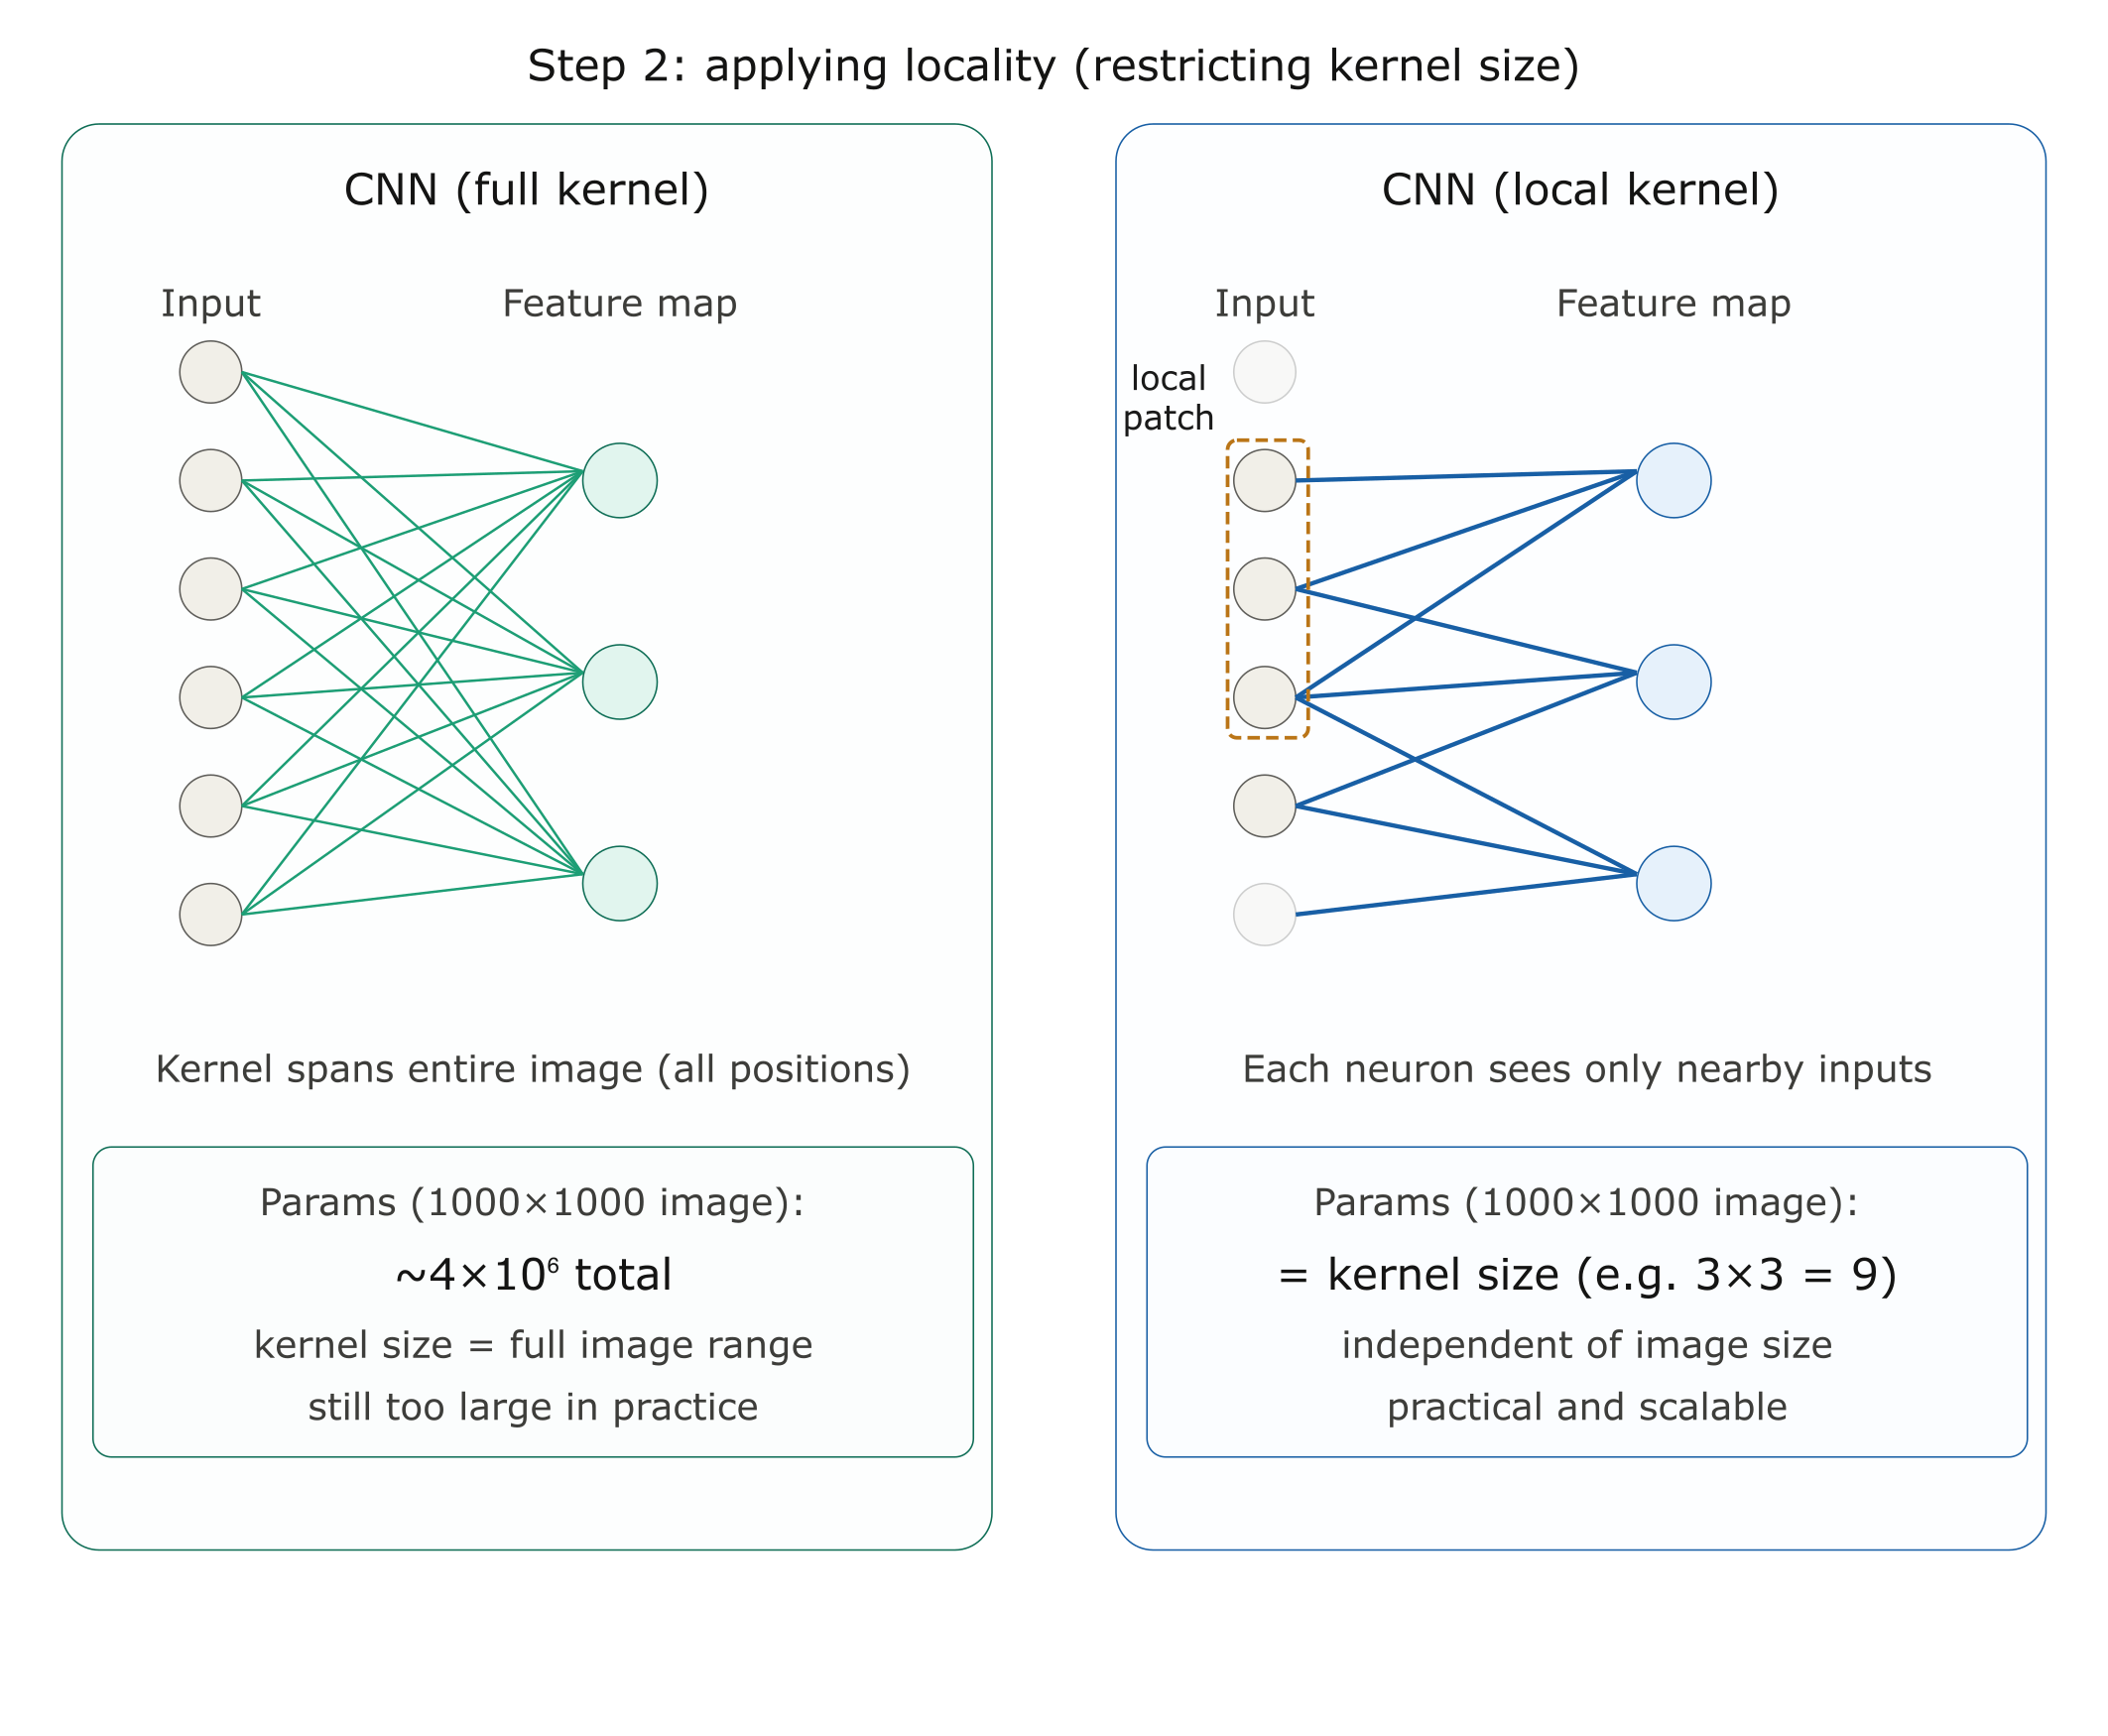

In [3]:
display(Image('./Fig/02_fig2_cnn_full_vs_local_kernel.png', width=600))

$[\mathbf{H}]_{i, j}=u+\sum_{a=-\Delta}^{\Delta} \sum_{b=-\Delta}^{\Delta}[\mathbf{V}]_{a, b}[\mathbf{X}]_{i+a, j+b}$.

Now the convolution is restricted to a specific range in terms of $a$ and $b$. $\mathbf{V}$ is referred to as a convolution kernel, a filter, or simply the layer's weights that are learnable parameters.

<div style="background-color:#f0f4ff; border-left:5px solid #4a6fa5; padding:16px 20px; border-radius:6px; margin:16px 0; max-width:90%;">
<strong>📋 Brief Summary</strong>
<p>Convolution reduces parameters because it exploits two key assumptions:</p>
<ol>
<li><strong>Weight sharing:</strong> The same filter is applied everywhere in the image. This means you use one set of weights to scan the entire spatial dimension, rather than learning separate weights for each location. Weight sharing leverages the assumption of <em>translation invariance</em> — the idea that features that are useful in one part of the image are also useful elsewhere.</li>
<li><strong>Local connectivity:</strong> Each neuron only looks at a small region, not the entire input. This means you need far fewer weights per neuron than in a fully connected layer.</li>
</ol>
</div>

### 1.3 Feature maps (illustrative examples: what they look like, what they detect)

When a CNN applies a filter to an input image, it produces a 2D grid of responses called a feature map. Each value in the feature map represents how strongly that filter's pattern was detected at a particular spatial location. Applying multiple filters produces multiple feature maps, one per filter, forming a stack that grows deeper as the network learns more patterns.

<strong>💡 What do feature maps detect?</strong>

Feature maps are learned from data. However, a consistent pattern emerges across different networks and tasks: the complexity of detected features increases with depth.
- Early layers detect simple, low-level patterns: edges, corners, color gradients
- Middle layers combine these into textures, shapes, and repeated structures
- Deeper layers respond to high-level concepts: object parts, semantic regions

In the context of industrial defect detection, this hierarchy is particularly intuitive:
- Early feature maps highlight sharp intensity changes - the boundary of a scratch
- Middle feature maps capture elongated structures - the shape of a crack
- Deeper feature maps encode defect-like regions - combinations of shape, texture, and contrast that distinguish a defect from normal steel surface

## 2. What is exactly happening when we are doing convolutions for images?

### 2.1 The cross-correlation operation

In the two-dimensional cross-correlation operation, we begin with the convolution window positioned at the upper-left corner of the input tensor and slide it across the input tensor, both from left to right and top to bottom. 

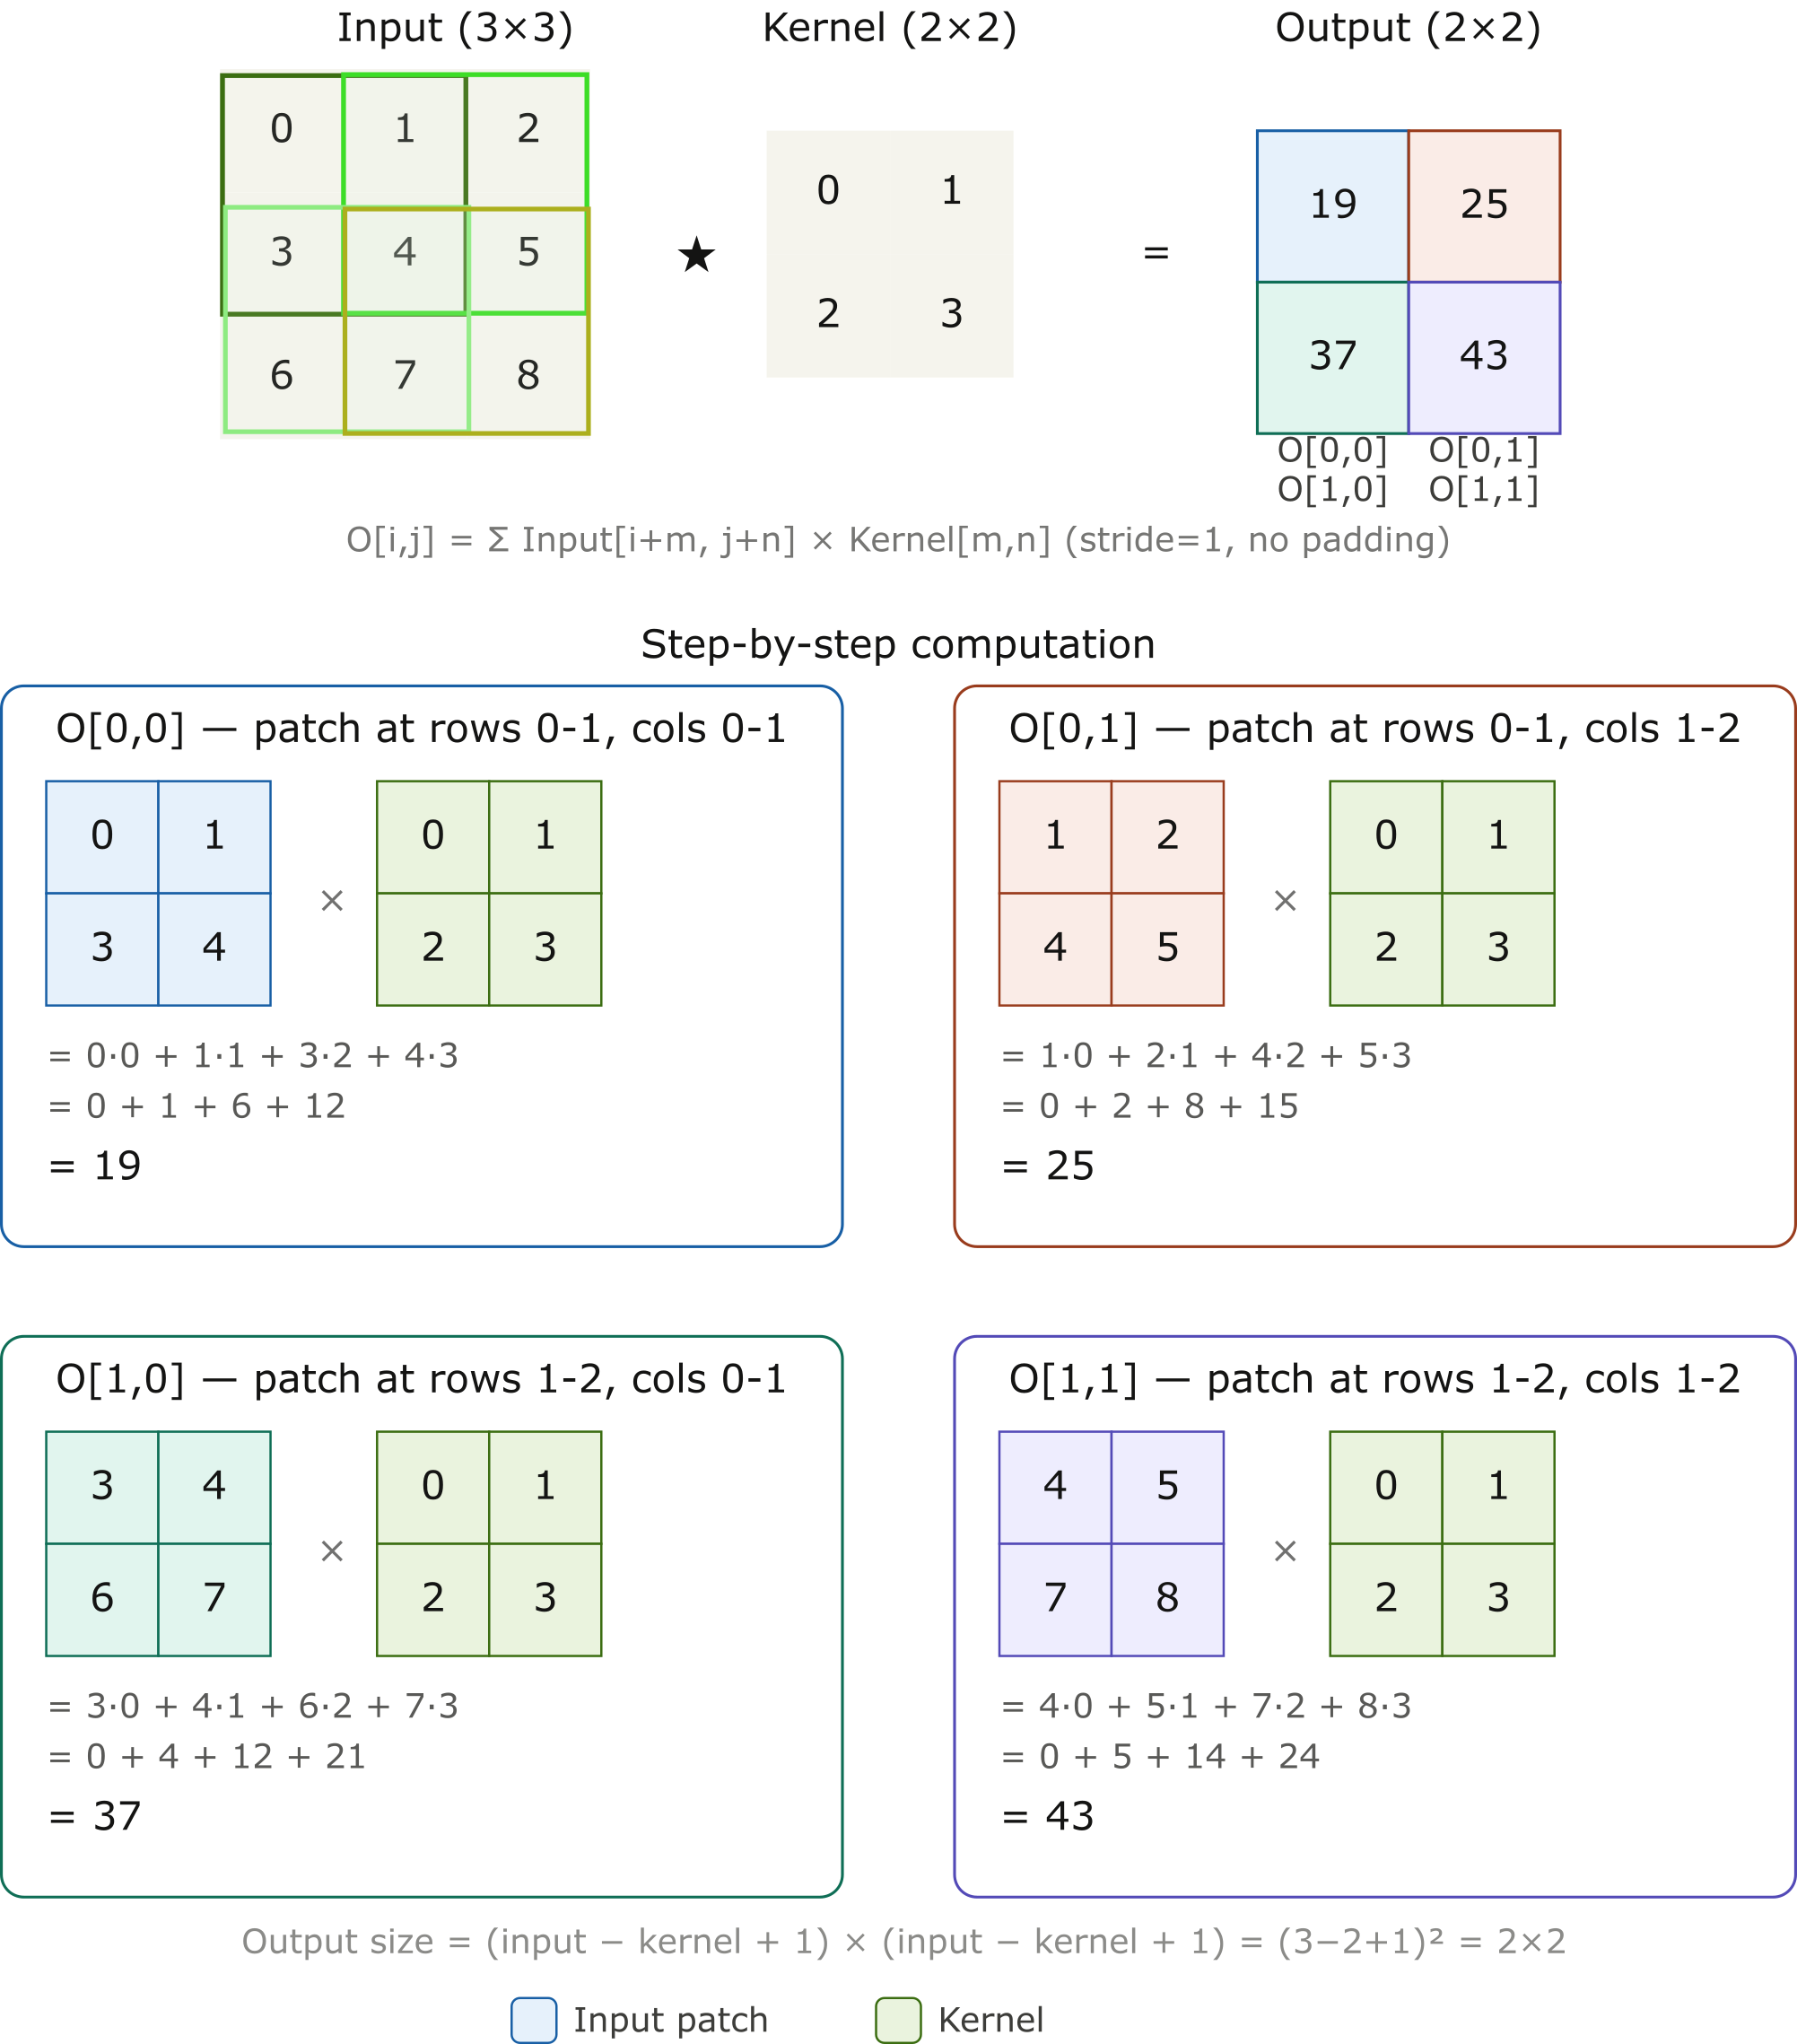

In [4]:
display(Image('./Fig/02_cross_correlation_2d_clean2.png', width=600))

The output size is given by the input size $n_{\mathrm{h}} \times n_{\mathrm{w}}$ minus the size of the convolution kernel $k_{\mathrm{h}} \times k_{\mathrm{w}}$ via
$\left(n_{\mathrm{h}}-k_{\mathrm{h}}+1\right) \times\left(n_{\mathrm{w}}-k_{\mathrm{w}}+1\right)$.

In [172]:
import torch
from torch import nn

# corr2d function, which accepts an input tensor X and a kernel tensor K and returns an output tensor Y
def corr2d(X, K):  #@save
    """Compute 2D cross-correlation."""
    h, w = K.shape
    Y = torch.zeros((X.shape[0] - h + 1, X.shape[1] - w + 1))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            Y[i, j] = (X[i:i + h, j:j + w] * K).sum()
    return Y

In [173]:
X = torch.tensor([[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]])
K = torch.tensor([[0.0, 1.0], [2.0, 3.0]])
corr2d(X, K)

tensor([[19., 25.],
        [37., 43.]])

### 2.2 Convolution layers

In [174]:
class Conv2D(nn.Module):
    def __init__(self, kernel_size):
        super().__init__()
        self.weight = nn.Parameter(torch.rand(kernel_size))
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        return corr2d(x, self.weight) + self.bias

<strong>💡 How to design a kernel?</strong>

In [175]:
# Example: kernel for edge detection
X = torch.ones((5, 8))
X[:, 2:6] = 0
X

tensor([[1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.]])

In [176]:
K = torch.tensor([[1.0, -1.0]])

In [177]:
Y = corr2d(X, K)
Y

tensor([[ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.]])

If we know precisely what we are looking for, designing an edge detector by finite differences [-1, 1] is neat.
However, as we look at larger kernels, and consider successive layers of convolutions, it might be impossible to specify precisely what each filter should be doing manually.

In this case, we would like to learn the kernel that generated Y from X by looking at the input–output pairs only.

In [178]:
# Construct a two-dimensional convolutional layer with 1 output channel and a
# kernel of shape (1, 2). For the sake of simplicity, we ignore the bias here
conv2d = nn.LazyConv2d(1, kernel_size=(1, 2), bias=False)
# Note: LazyConv2d infers in_channels automatically on the first forward pass.
# The equivalent explicit version would be:
# conv2d = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=(1, 2), bias=False)
#
# Throughout this theory section we use LazyConv2d for brevity and consistency
# with the course reference (d2l.ai). In the hands-on exercises you will use
# nn.Conv2d with explicit dimensions, as is standard in practice.

# The two-dimensional convolutional layer uses four-dimensional input and
# output in the format of (example, channel, height, width), where the batch
# size (number of examples in the batch) and the number of channels are both 1
X = X.reshape((1, 1, 5, 8))
Y = Y.reshape((1, 1, 5, 7))
lr = 3e-2  # Learning rate

for i in range(10):
    Y_hat = conv2d(X)
    l = (Y_hat - Y) ** 2
    conv2d.zero_grad()
    l.sum().backward()
    # Update the kernel
    conv2d.weight.data[:] -= lr * conv2d.weight.grad
    if (i + 1) % 2 == 0:
        print(f'epoch {i + 1}, loss {l.sum():.3f}')

epoch 2, loss 6.059
epoch 4, loss 1.453
epoch 6, loss 0.349
epoch 8, loss 0.084
epoch 10, loss 0.020


In [179]:
conv2d.weight.data.reshape((1, 2))

tensor([[ 0.9686, -0.9686]])

> The learned kernel tensor is remarkably close to the kernel tensor K we defined earlier.

### 2.3 Feature maps & receptive field (now with equations and tensor notation)

Before diving into the details, it is worth understanding what these two concepts are fundamentally about and how they relate to CNN design:
- Feature maps are tied to channel depth - the more filters a layer applies, the more feature maps it produces, and the richer the representation at each spatial location. Adding filters asks: "what else is present here?"
- Receptive field is tied to network depth - each additional layer expands the region of the original input that influences a single output neuron. Adding layers asks: "how much of the image can I see?"

Together they explain the two core design choices in CNN architectures: how wide (channel depth) and how deep (network depth) a network should be.

These are not abstract principles. They directly shape real architectures. LeNet, one of the earliest and most influential CNN architectures which we will study in Section 3, already embodies both ideas: it stacks multiple convolutional layers to grow the receptive field, while increasing channel depth across layers to learn richer feature representations. What may seem like simple design choices here will become concrete architectural decisions when we examine LeNet in detail.

#### 2.3.1 Color (Input) Channels vs. Feature Maps (Output Channels)

One image usually consists of three input channels: red, green, and blue. We denote the raw image as $[\mathbf{X}]_{i, j, c}$, where $c \in\{0,1,2\}$ indexes the color channel.

When a CNN applies a filter to this image, it slides a small kernel over all input channels and produces a single 2D grid as output. To learn richer representations, the CNN applies multiple filters - each filter scans all input channels independently and produces one output channel. The result is a stack of feature maps, which increases the depth (channel dimension) of the representation.

Understanding depth increase:
- One filter applied to grayscale ( $[\mathbf{X}]_{i, j}$, one input channel): produces one 2D grid.
- One filter applied to RGB ( $[\mathbf{X}]_{i, j, c}$, three input channels): still produces one 2D grid (the filter weights span all three color channels).
- $D$ filters applied to RGB: produces $D$ stacked 2D grids, forming a hidden representation $[\mathbf{H}]_{i, j, d}$ with $D$ output channels (feature maps).

The spatial dimensions [ $H, W$ ] remain roughly constant as the signal passes through the network; the channel dimension grows as we apply more filters. This depth increase is how networks learn hierarchical features: early layers detect simple patterns (edges), later layers detect complex shapes by combining those edges.

Mathematical notation:

$$
[\mathbf{H}]_{i, j, d}=\sum_{a=-\Delta}^{\Delta} \sum_{b=-\Delta}^{\Delta} \sum_{c=0}^{C_{\mathrm{in}}-1}[\mathbf{V}]_{a, b, c, d}[\mathbf{X}]_{i+a, j+b, c}
$$

where:
- $[\mathbf{X}]_{i, j, c}$ is the input with $C_{\text {in }}$ input channels (e.g., 3 for RGB or 1 for grayscale)
- $[\mathbf{V}]_{a, b, c, d}$ are the filter weights; each index $d$ is one complete filter
- $[\mathbf{H}]_{i, j, d}$ is the output with $D$ output channels (feature maps), where $d \in \{0,1, \ldots, D-1\}$

Each output channel $d$ learns to detect a different pattern (edges, textures, shapes, etc.) by combining information across all input channels and spatial positions. The depth of the output increases with the number of filters-this is the primary way CNNs increase representational power as data flows through the network.

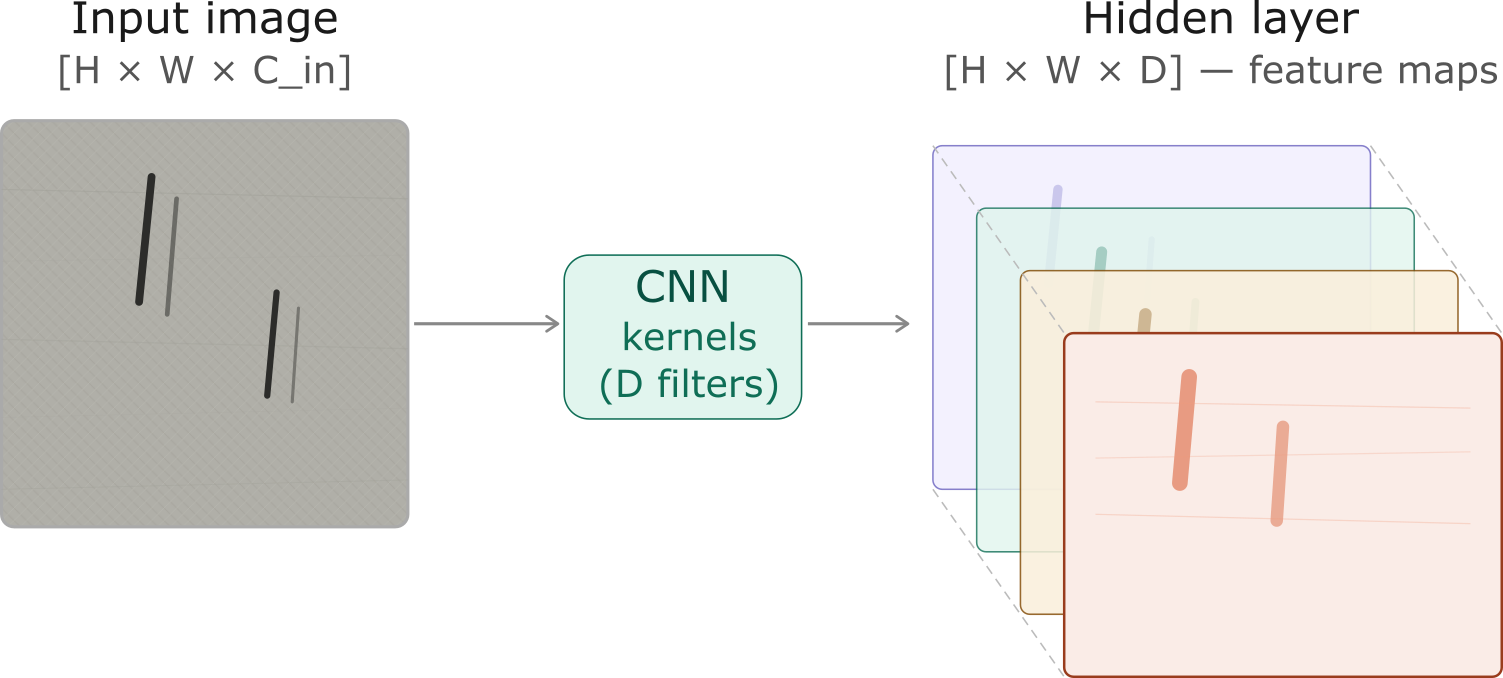

In [5]:
display(Image('./Fig/02_cnn_third_order_tensor3.png', width=600))

In [163]:
# Here we first restrict ourselves to the simplified case where both input and output layers have only one channel.
import torch.nn as nn

conv = nn.Conv2d(
    in_channels=1,
    out_channels=1,
    kernel_size=3,
    bias=True,
)

# overall structure
print(conv)

# kernel V: shape [out_ch, in_ch, kH, kW]
# Note: weights are randomly initialized (not learned yet)
print("kernel [V] shape :", conv.weight.shape)
print("kernel [V] values:", conv.weight)

# bias u: shape [out_ch]
print("bias [u] shape :", conv.bias.shape)
print("bias [u] value :", conv.bias)

# total trainable parameters
total = sum(p.numel() for p in conv.parameters())
print("total params :", total)

Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1))
kernel [V] shape : torch.Size([1, 1, 3, 3])
kernel [V] values: Parameter containing:
tensor([[[[ 0.0903,  0.2573,  0.1504],
          [ 0.0803,  0.3247, -0.2501],
          [-0.0209,  0.1989, -0.1891]]]], requires_grad=True)
bias [u] shape : torch.Size([1])
bias [u] value : Parameter containing:
tensor([0.0726], requires_grad=True)
total params : 10


#### 2.3.2 Receptive field

In CNNs, for any element of some layer, its receptive field refers to all the elements (from all the previous layers) that may affect the calculation of during the forward propagation. When any element in a feature map needs a larger receptive field to detect input features over a broader area, we can build a deeper network.

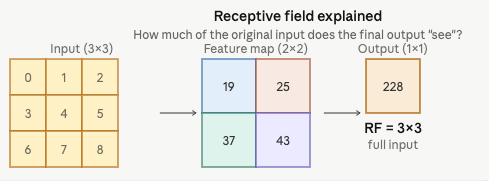

In [6]:
display(Image('./Fig/02_Receptive_field.png', width=500))

<strong>&#8505; Interesting to know</strong>

The concept of receptive fields did not originate in deep learning. It was borrowed from neuroscience. Hubel and Wiesel's experiments on the visual cortex showed that neurons in early visual areas respond to local patterns like edges, not the entire visual field. This mirrors exactly what CNN feature maps learn: early layers detect edges and simple textures, deeper layers combine these into complex shapes.

This is not a coincidence. CNNs were partly inspired by biology, and the striking similarity between learned convolutional filters and biological visual receptors helps explain why convolutions work so well for image understanding.

> *Nature arrived at the same solution first.*

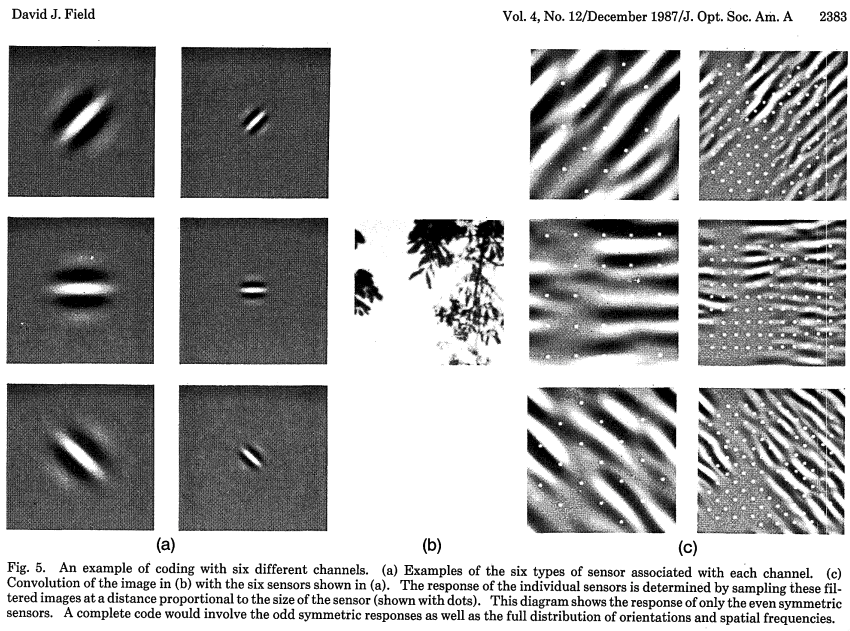

In [7]:
#Field, D. J. (1987). Relations between the statistics of natural images and the 
# response properties of cortical cells. JOSA A, 4(12), 2379–2394.
display(Image('./Fig/02_David_kernel.png', width=700))

### 2.4 Techniques for control over the size of the output

If we start with an image having 240 $\times$ 240 pixels, applying a convolutional kernel of 5 $\times$ 5 by 10 layers reduces the image to 200 $\times$ 200 pixels, slicing off 30% of the image and destroying interesting information on the boundaries of the original image.

#### 2.4.1 Padding

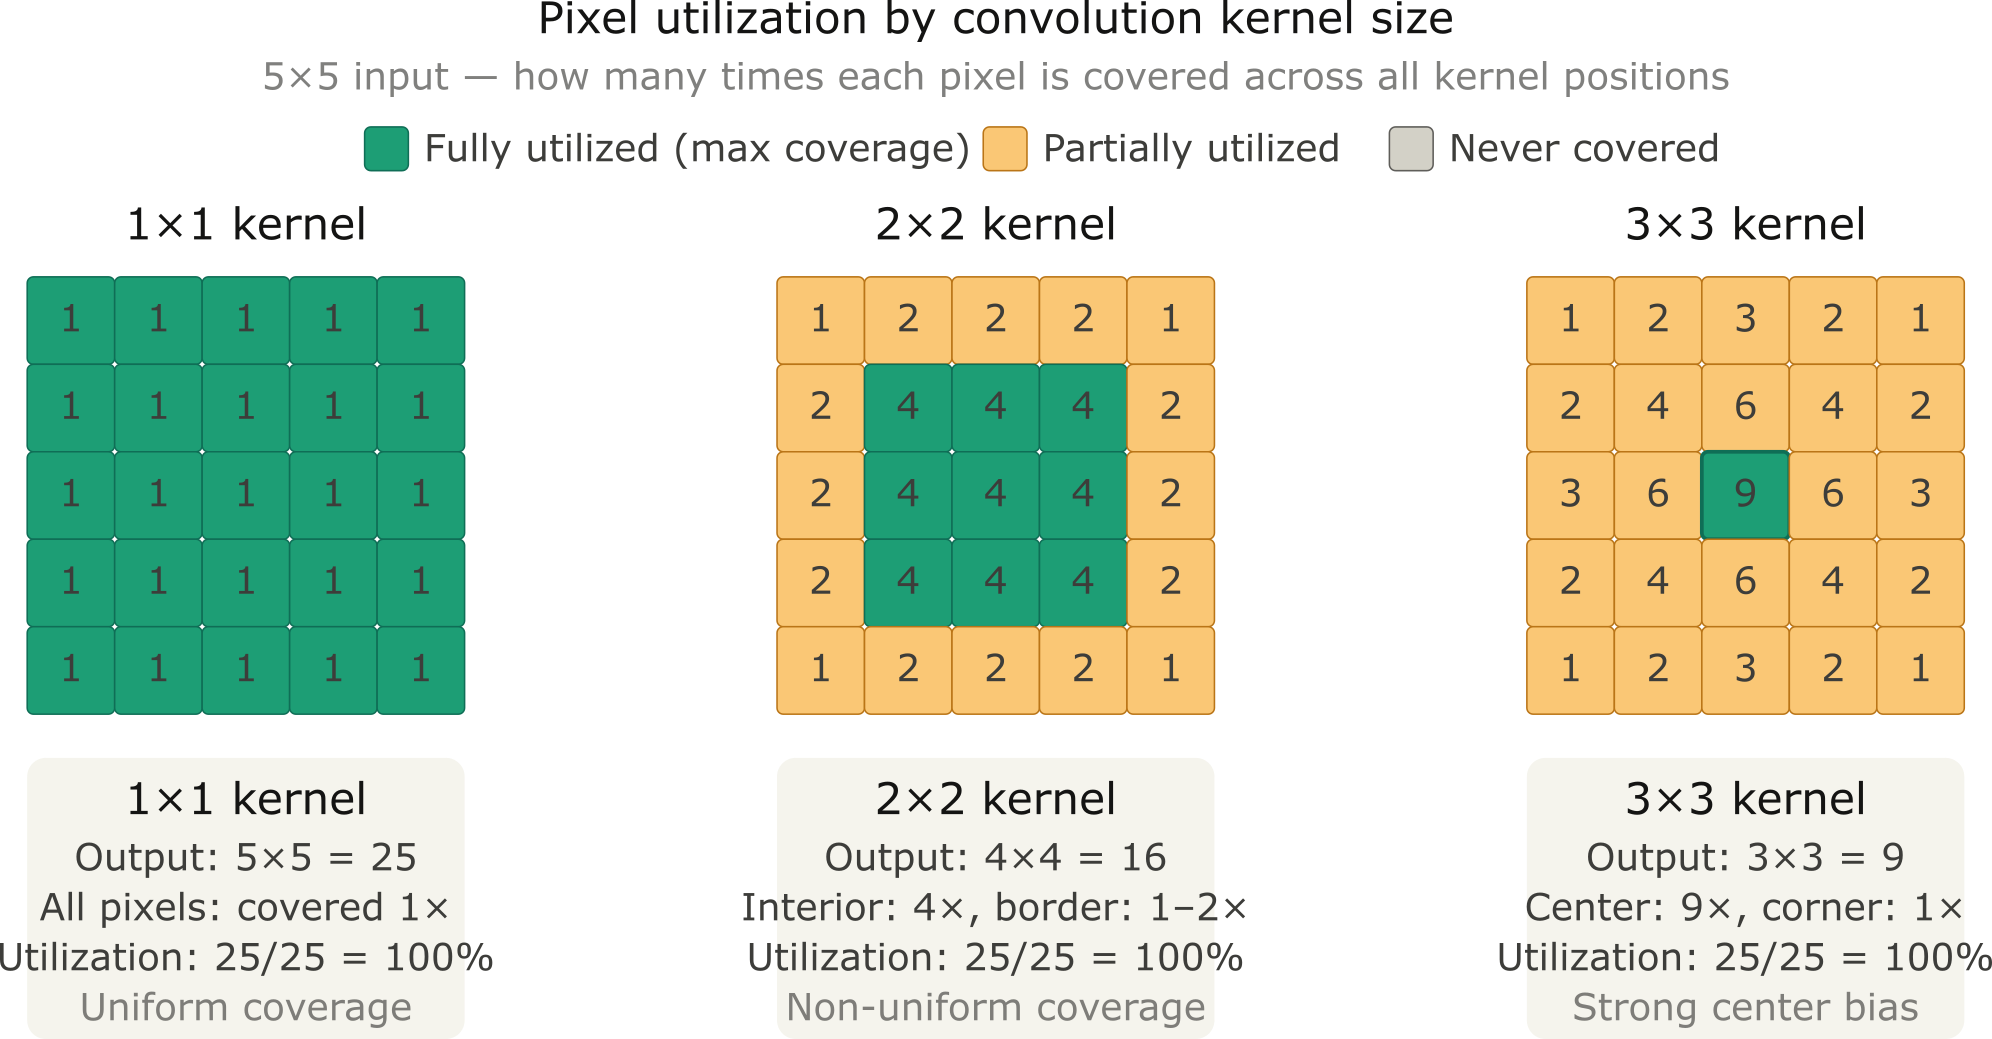

In [8]:
display(Image('./Fig/02_pixel_utilization_convolutions.png', width=700))

One straightforward solution to this problem is to add extra pixels of filler around the boundary of our input image, thus increasing the effective size of the image.

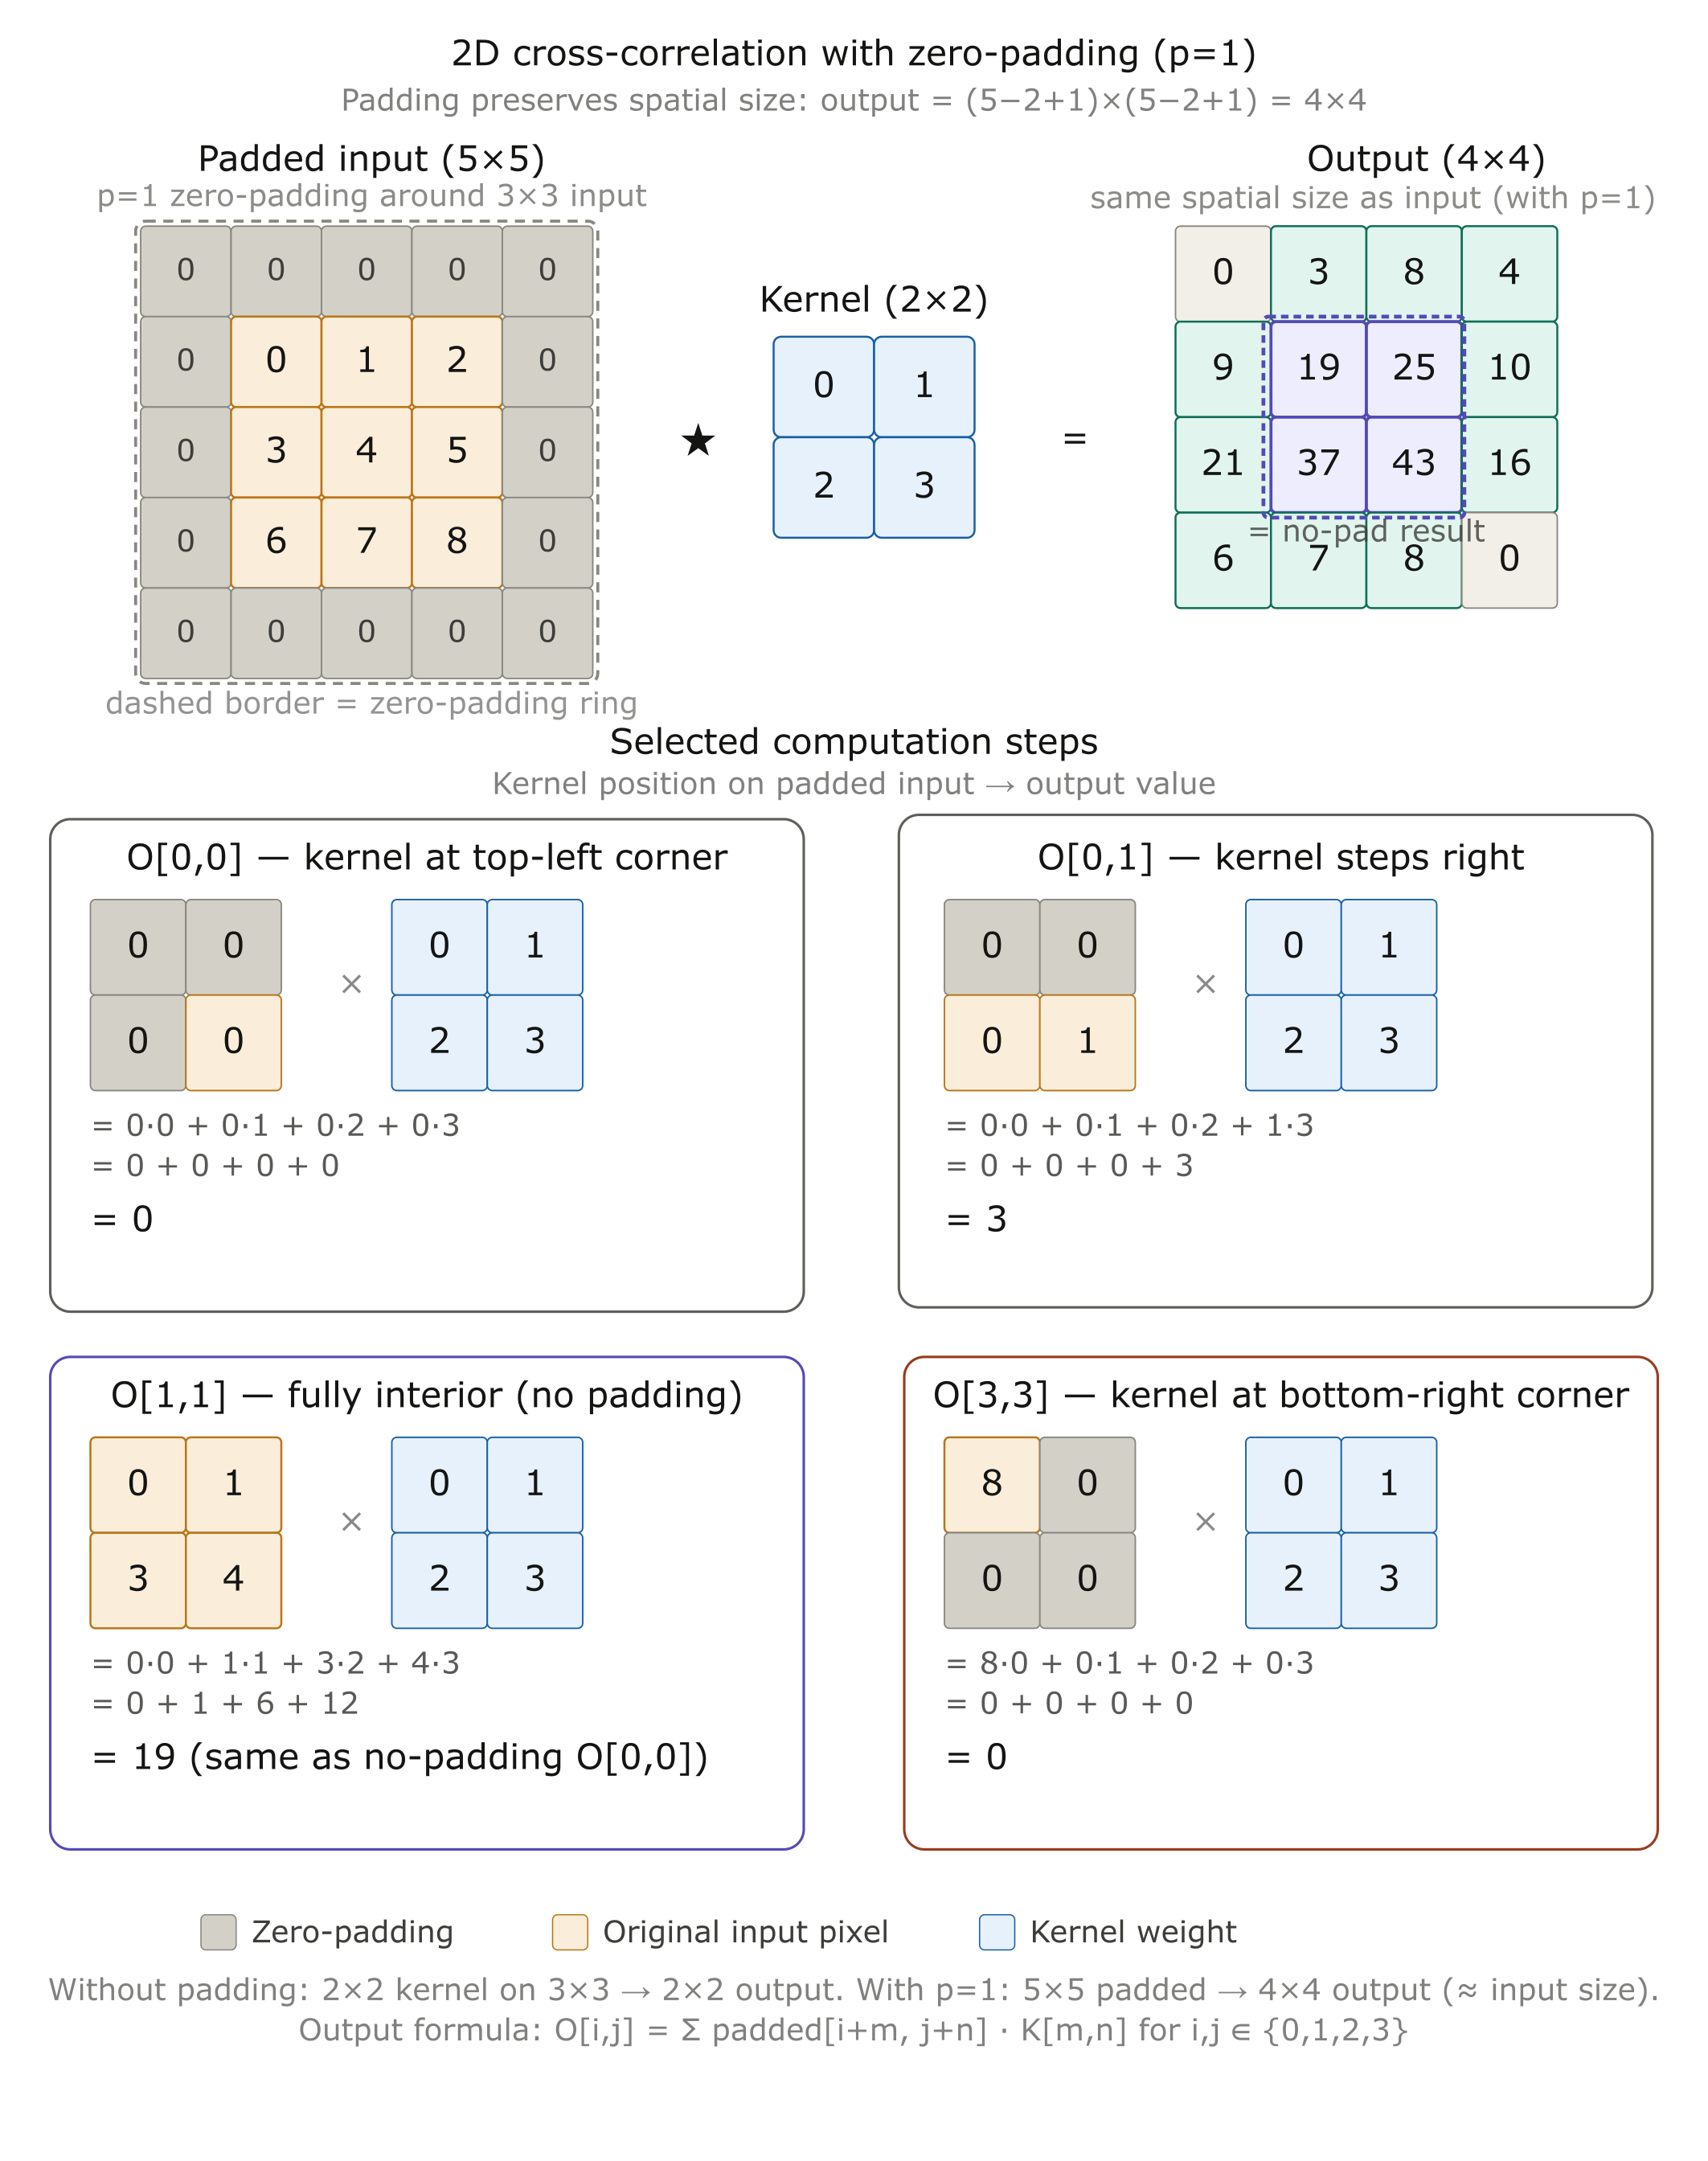

In [9]:
display(Image('./Fig/02_cross_correlation_2d_padding2.png', width=700))

In general, if we add a total of $p_{\mathrm{h}}$ rows of padding and a total of $p_{\mathrm{w}}$ columns of padding, the output shape will be

$$
\left(n_{\mathrm{h}}-k_{\mathrm{h}}+p_{\mathrm{h}}+1\right) \times\left(n_{\mathrm{w}}-k_{\mathrm{w}}+p_{\mathrm{w}}+1\right) .
$$

In many cases, we prefer to set $p_{\mathrm{h}}=k_{\mathrm{h}}-1$ and $p_{\mathrm{w}}=k_{\mathrm{w}}-1$ to give the input and output the same height and width. 

CNNs commonly use convolution kernels with odd height and width values, such as 1, 3, 5, or 7. 
By choosing odd kernel sizes:
1. we can preserve the dimensionality while padding with the same number of rows on top and bottom, and the same number of columns on left and right;
2. we know that the output $\mathrm{Y}[\mathrm{i}, \mathrm{j}]$ is calculated by cross-correlation of the input and convolution kernel with the window centered on $\mathrm{X}[\mathrm{i}, \mathrm{j}]$.

In [48]:
# We define a helper function to calculate convolutions. It initializes the
# convolutional layer weights and performs corresponding dimensionality
# elevations and reductions on the input and output
def comp_conv2d(conv2d, X):
    # (1, 1) indicates that batch size and the number of channels are both 1
    X = X.reshape((1, 1) + X.shape)
    Y = conv2d(X)
    # Strip the first two dimensions: examples and channels
    return Y.reshape(Y.shape[2:])

# 1 row and column is padded on either side, so a total of 2 rows or columns
# are added
conv2d = nn.LazyConv2d(1, kernel_size=3, padding=1)
X = torch.rand(size=(8, 8))
comp_conv2d(conv2d, X).shape

torch.Size([8, 8])

In [49]:
# We use a convolution kernel with height 5 and width 3. The padding on either
# side of the height and width are 2 and 1, respectively
conv2d = nn.LazyConv2d(1, kernel_size=(5, 3), padding=(2, 1))
comp_conv2d(conv2d, X).shape

torch.Size([8, 8])

Besides zero-padding (significant computational benefit; allowing CNNs to encode implicit position information within an image), there are many alternatives. For further reading, please refer to the paper below:

Alsallakh, B., Kokhlikyan, N., Miglani, V., Yuan, J., & Reblitz-Richardson, O. (2020). Mind the PAD – CNNs can develop blind spots. ArXiv:2010.02178.

#### 2.4.2 Stride

In previous section, we defaulted to sliding one element at a time. However, sometimes we want to move our window more than one element at a time by skipping the intermediate locations for computational efficiency or downsample. 

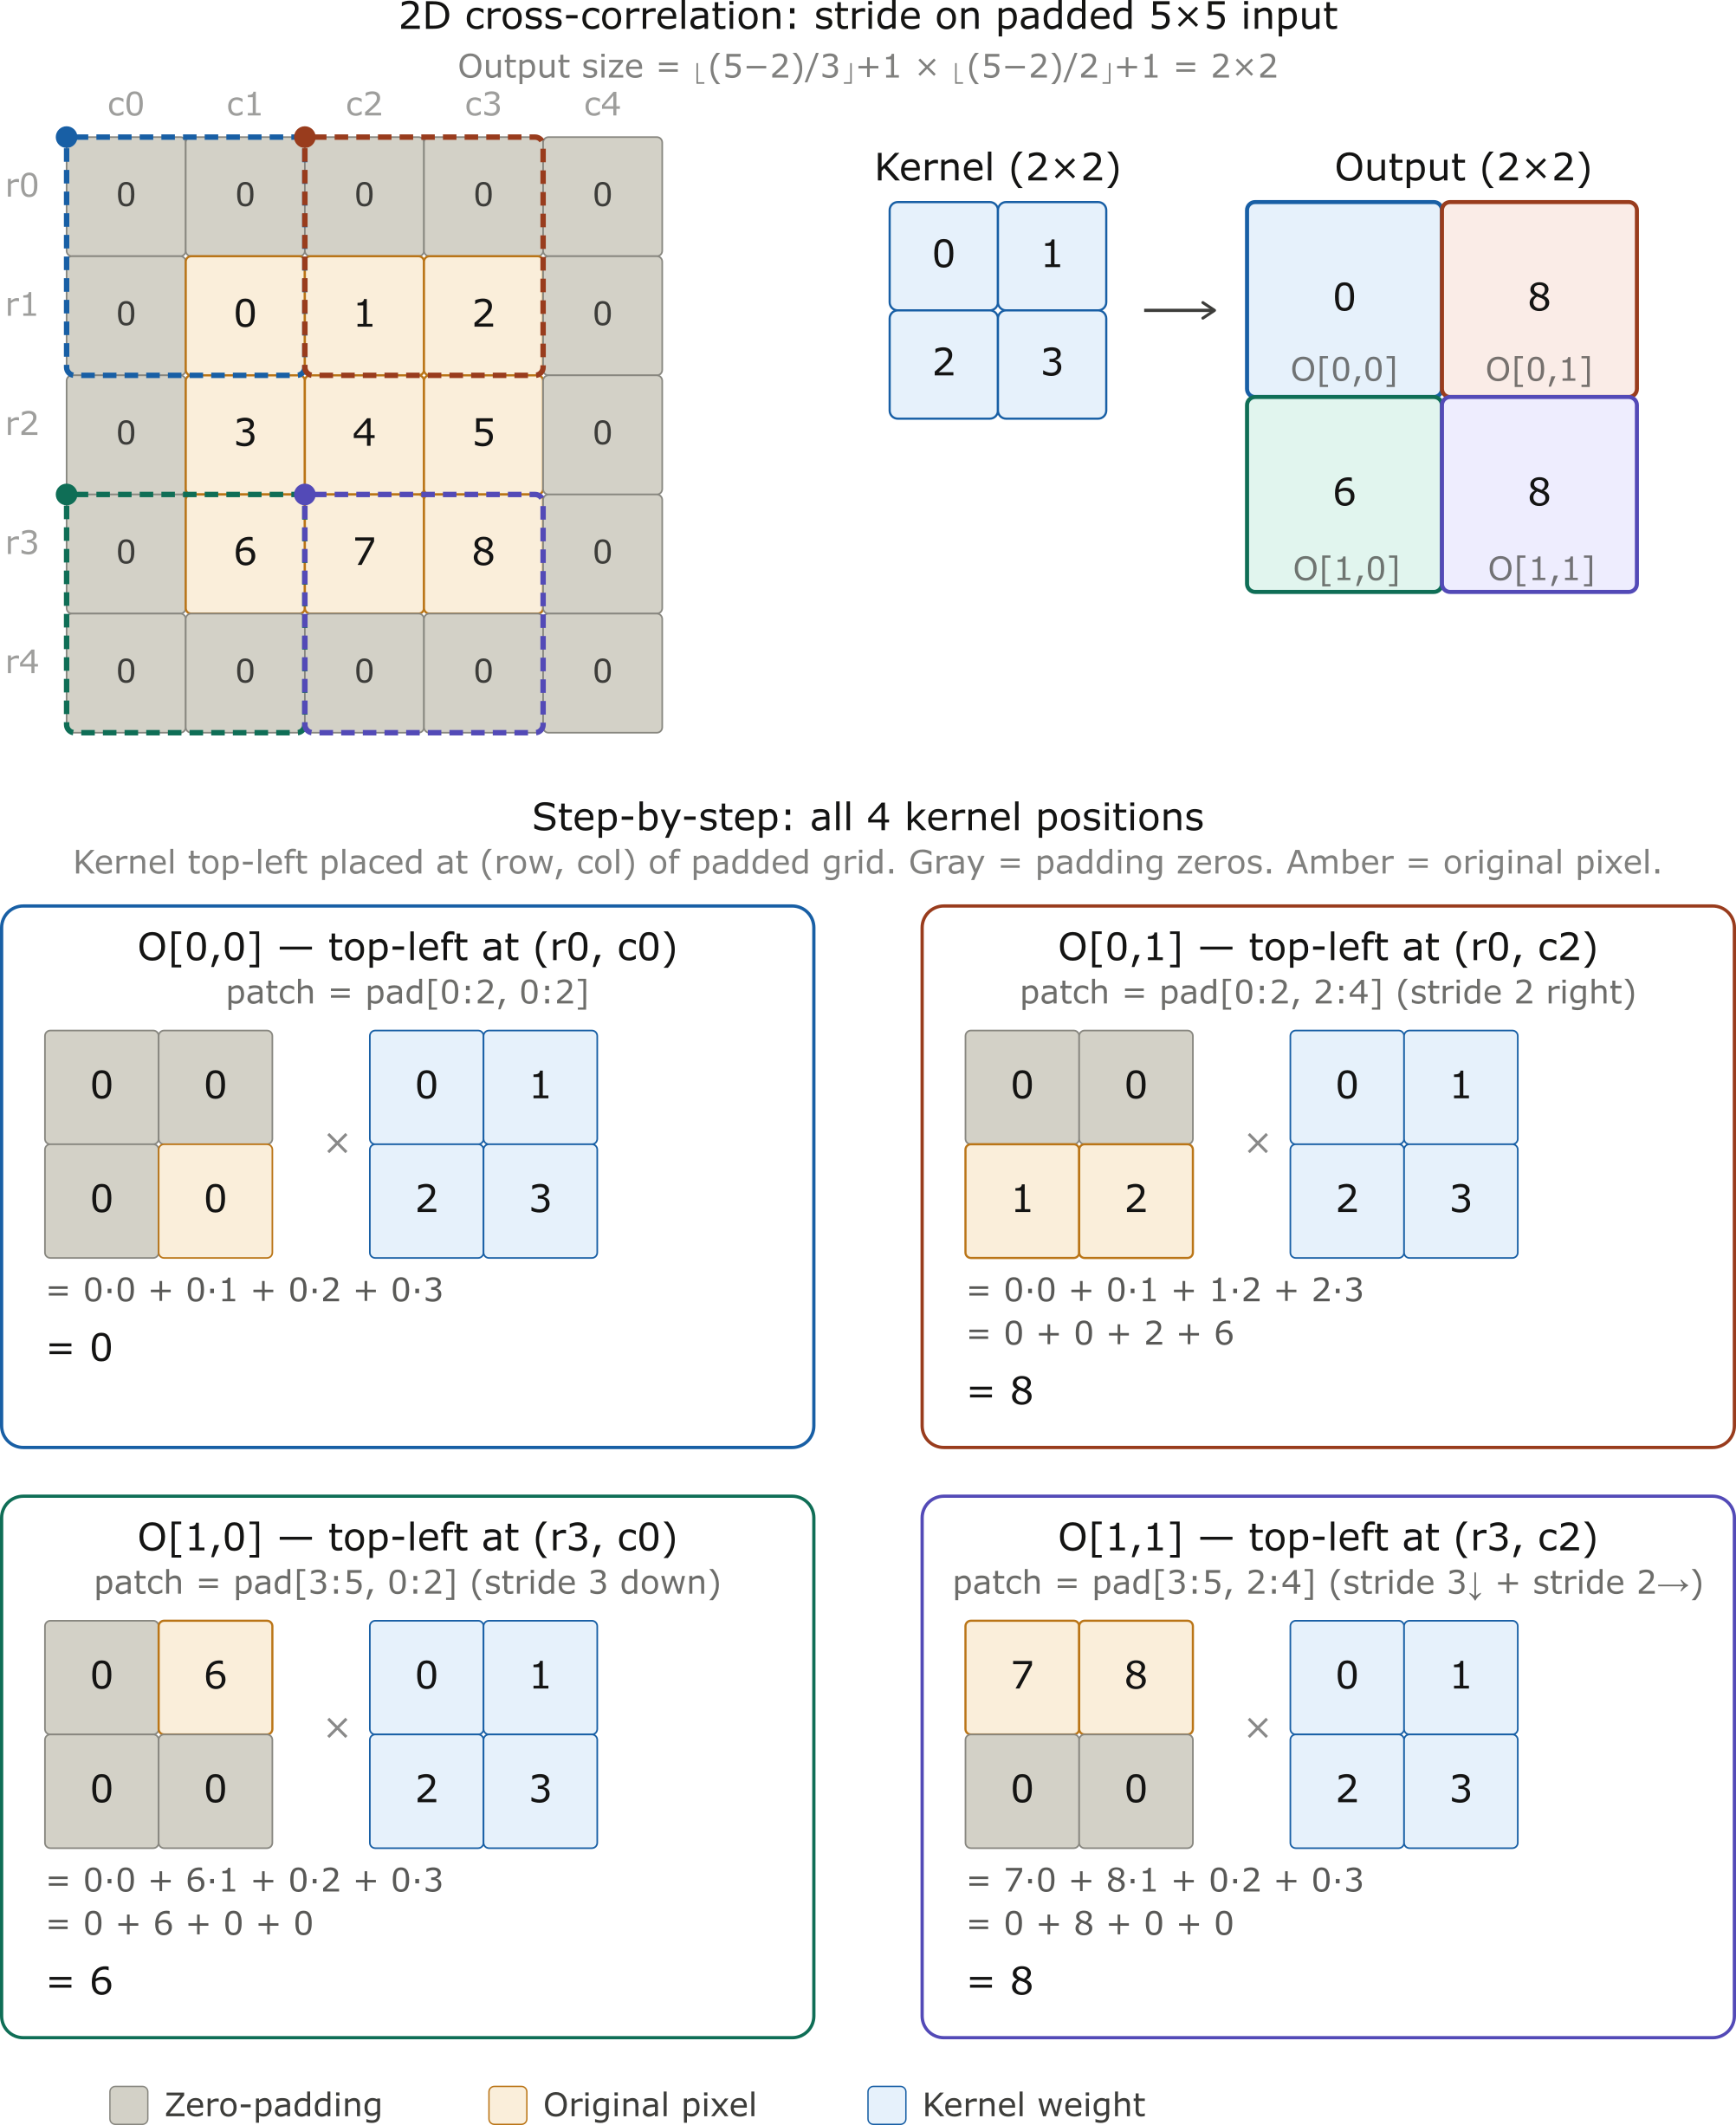

In [10]:
display(Image('./Fig/02_cross_correlation_stride_3v_2h.png', width=700))

In general, when the stride for the height is $s_{\mathrm{h}}$ and the stride for the width is $s_{\mathrm{w}}$, the output shape is

$$
\left[\left(n_{\mathrm{h}}-k_{\mathrm{h}}+p_{\mathrm{h}}+s_{\mathrm{h}}\right) / s_{\mathrm{h}}\right] \times\left[\left(n_{\mathrm{w}}-k_{\mathrm{w}}+p_{\mathrm{w}}+s_{\mathrm{w}}\right) / s_{\mathrm{w}}\right].
$$


If we set $p_{\mathrm{h}}=k_{\mathrm{h}}-1$ and $p_{\mathrm{w}}=k_{\mathrm{w}}-1$, then the output shape can be simplified to $\left[\left(n_{\mathrm{h}}+s_{\mathrm{h}}-1\right) / s_{\mathrm{h}}\right] \times\left[\left(n_{\mathrm{w}}+s_{\mathrm{w}}-1\right) / s_{\mathrm{w}}\right]$. 

If the input height and width are divisible by the strides on the height and width, then the output shape will be $\left(n_{\mathrm{h}} / s_{\mathrm{h}}\right) \times\left(n_{\mathrm{w}} / s_{\mathrm{w}}\right)$.

In [51]:
conv2d = nn.LazyConv2d(1, kernel_size=3, padding=1, stride=2)
comp_conv2d(conv2d, X).shape

torch.Size([4, 4])

In [52]:
conv2d = nn.LazyConv2d(1, kernel_size=(3, 5), padding=(0, 1), stride=(3, 4))
comp_conv2d(conv2d, X).shape

torch.Size([2, 2])

#### 2.4.3 Pooling

In many use cases, the practical question is regarding the global information of an image, for example, does it contain a defect? As a consequence, the units of our final layer should be sensitive to the entire input. This objective is achieved by gradually aggregating information, which yields coarser and coarser maps. In this way, we manage to learn a global representation, while keeping all of the advantages of convolutional layers at the intermediate layers of processing.

The further a neuron sits from the input layer, the more of the original image it can "see". Shrinking the feature map along the way amplifies this effect: once the map is smaller, the same-sized kernel covers more ground in the original image, so the network builds up a wide view faster.

In addition, besides **spatially downsampling representations**, the pooling layers also serve the purpose of **mitigating the sensitivity of convolutional layers to location**.

##### 2.4.3.1 Maximum pooling and average pooling

**Max-pooling** was introduced by Riesenhuber and Poggio (Riesenhuber, M., & Poggio, T. (1999). Nature Neuroscience, 2(11), 1019–1025) in the context of cognitive neuroscience to describe how information aggregation might be aggregated hierarchically for the purpose of object recognition. Actually, back to 1990, it was already used for speech recognition. 

The idea of **average pooling** is akin to downsampling an image. The information from multiple adjacent pixels is combined, in order to obtain an image with better signal-to-noise ratio.

In almost all cases, max-pooling is preferable to average pooling, as it confers some degree of invariance to output.

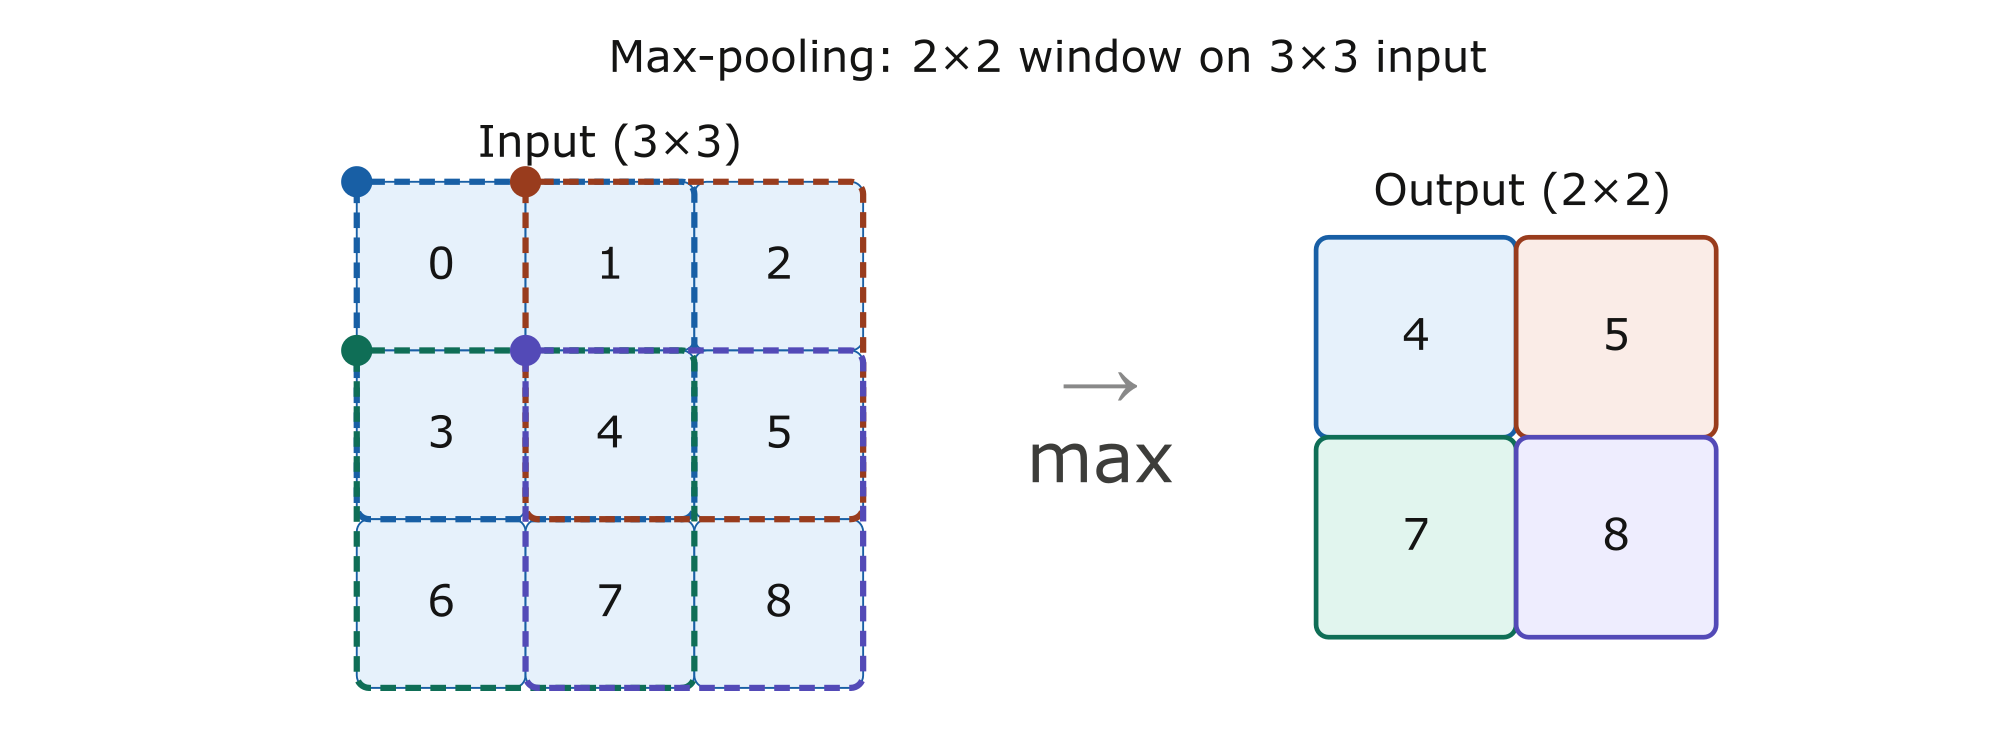

In [11]:
display(Image('./Fig/02_max_pooling_2x2_on_3x3.png', width=700))

Imagine an edge detection problem: if the image $X$ shows a sharp delineation between black and white, shifting the whole image by one pixel to the right, i.e., $Z[i, j]=X[i, j+1]$, might make the new image look totally different. 

In this case, using a $2 \times 2$ max-pooling layer, regardless of whether or not the values of $X[i, j], X[i, j+ 1], X[i+1, j]$ and $X[i+1, j+1]$ are different, the pooling layer always outputs $Y[i, j]=1$. 

In [141]:
def pool2d(X, pool_size, mode='max'):
    p_h, p_w = pool_size
    Y = torch.zeros((X.shape[0] - p_h + 1, X.shape[1] - p_w + 1))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            if mode == 'max':
                Y[i, j] = X[i: i + p_h, j: j + p_w].max()
            elif mode == 'avg':
                Y[i, j] = X[i: i + p_h, j: j + p_w].mean()
    return Y

In [142]:
X_mp = torch.tensor([[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]])
pool2d(X_mp, (2, 2))

tensor([[4., 5.],
        [7., 8.]])

In [144]:
pool2d(X_mp, (2, 2), 'avg')

tensor([[2., 3.],
        [5., 6.]])

##### 2.4.3.2 Padding and stride in pooling layer

**Motivation: Why adjust stride and padding?**
In real CNN architectures, we need flexibility in how we reduce spatial dimensions.
Different layers require different strategies:
- **Aggressive reduction**: When feature maps are large, we want to reduce computation quickly
- **Preserve detail**: When we need to keep spatial information for subsequent layers
- **Non-uniform reduction**: When input has non-square aspect ratios or asymmetric dimensions

Let's see how stride and padding give us this control.

In [147]:
#Create a simple input tensor
X_ps = torch.arange(16, dtype=torch.float32).reshape((1, 1, 4, 4))
X_ps
#This creates a 4×4 feature map with predictable values (0 to 15). 
#Sequential values make it clear which maximum value pooling selects.

tensor([[[[ 0.,  1.,  2.,  3.],
          [ 4.,  5.,  6.,  7.],
          [ 8.,  9., 10., 11.],
          [12., 13., 14., 15.]]]])

Since pooling aggregates information from an area, deep learning frameworks default to matching pooling window sizes and stride. 

In [148]:
#Aggressive spatial reduction (stride = kernel_size)
pool2d = nn.MaxPool2d(3)
# Pooling has no model parameters, hence it needs no initialization
pool2d(X_ps)

tensor([[[[10.]]]])

Configuration:
- Kernel size: $3 \times 3$
- Stride: Defaults to 3 (non-overlapping windows)
- Padding: Defaults to 0

When you have large feature maps and want to reduce computation, use stride = kernel_size for non-overlapping pooling. Each region is pooled exactly once with no overlap.

What happens:
- The $3 \times 3$ window slides with stride 3 across the $4 \times 4$ input
- Only one complete window fits (at position $[0: 3,0: 3]$ ), capturing values $0-11$
- Maximum value in that window: $\mathbf{1 0}$
- Output shape: [1, 1, 1, 1] (drastic reduction!)

When to use this:
- Early-stage spatial reduction in deep networks
- When you want maximal compression before dense layers
- Trade-off: lose fine spatial details

**Controlled reduction with overlapping windows (stride < kernel_size)**

In [149]:
pool2d = nn.MaxPool2d(3, padding=1, stride=2)
pool2d(X_ps)

tensor([[[[ 5.,  7.],
          [13., 15.]]]])

Configuration:
- Kernel size: $3 \times 3$
- Stride: 2 (overlapping windows-stride < kernel_size)
- Padding: 1 (add one row/column of zeros around edges)

When to use this:
- Mid-layer spatial reduction in residual or multi-scale architectures
- When you want to preserve local structure before further convolutions
- Trade-off: more computation than non-overlapping pooling, but retains more signal

**Non-uniform reduction for non-square feature maps**

In [153]:
pool2d = nn.MaxPool2d((2, 3), stride=(2, 3), padding=(0, 1))
pool2d(X_ps)

tensor([[[[ 5.,  7.],
          [13., 15.]]]])

In real networks, a previous convolutional layer might have reduced width more than height (or vice versa). Use non-uniform kernel sizes and strides to handle asymmetric feature maps.

Consider it when your input is inherently non-square, e.g., spectrograms in audio processing, panoramic images, or document scans, where you want to reduce height and width at different rates to progressively balance the aspect ratio across layers.

<div style="background-color:#f0f4ff; border-left:5px solid #4a6fa5; padding:16px 20px; border-radius:6px; margin:16px 0; max-width:90%;">
<strong>📋 Key Takeaway</strong>
<p>Pooling is not just a fixed operation. The choice of stride and padding determines how aggressively you reduce spatial dimensions and how much detail you preserve. Good CNN design carefully controls these parameters at each layer to balance computation efficiency with feature preservation.</p>
</div>

#### 2.4.4 An overview of CNN architecture so far

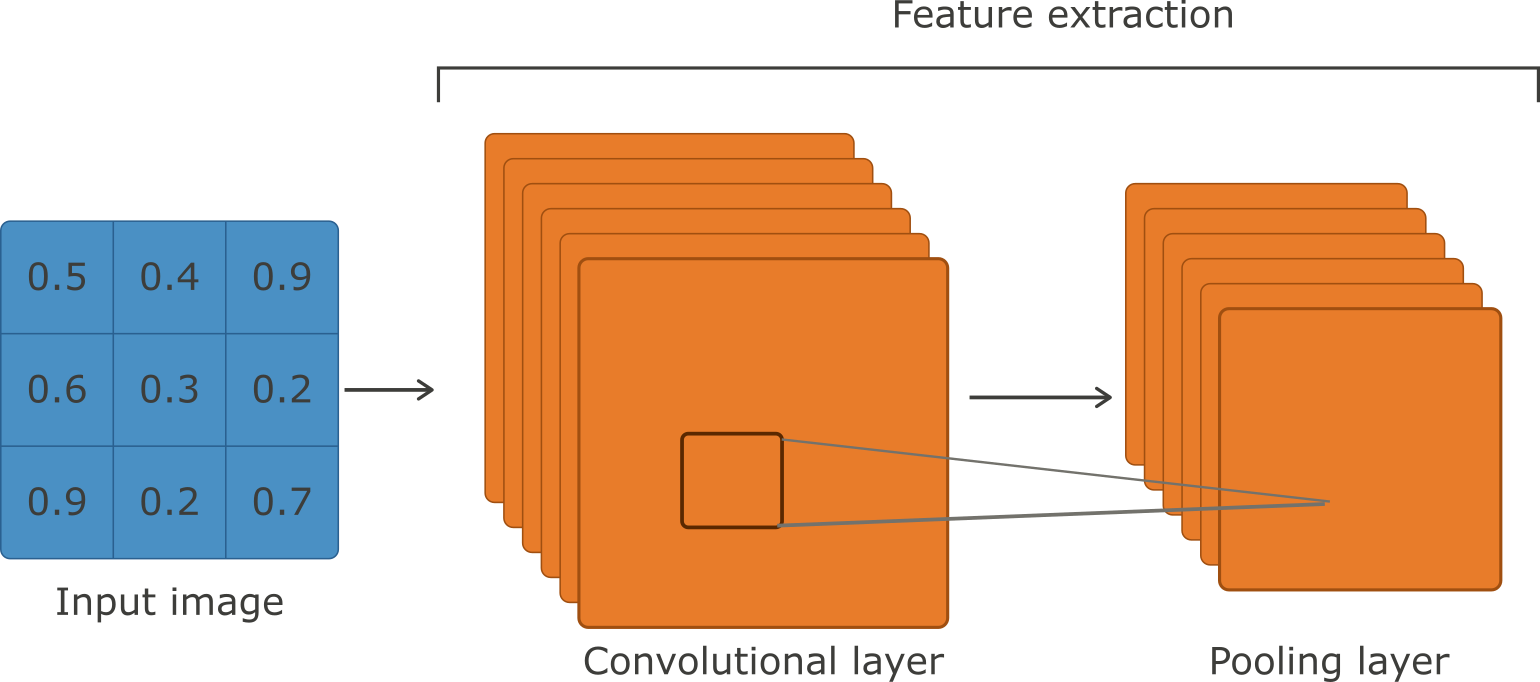

In [12]:
display(Image('./Fig/02_cnn_feature_extraction.png', width=500))

### 2.5 Multiple input and multiple output channels

#### 2.5.1 Multiple input channels

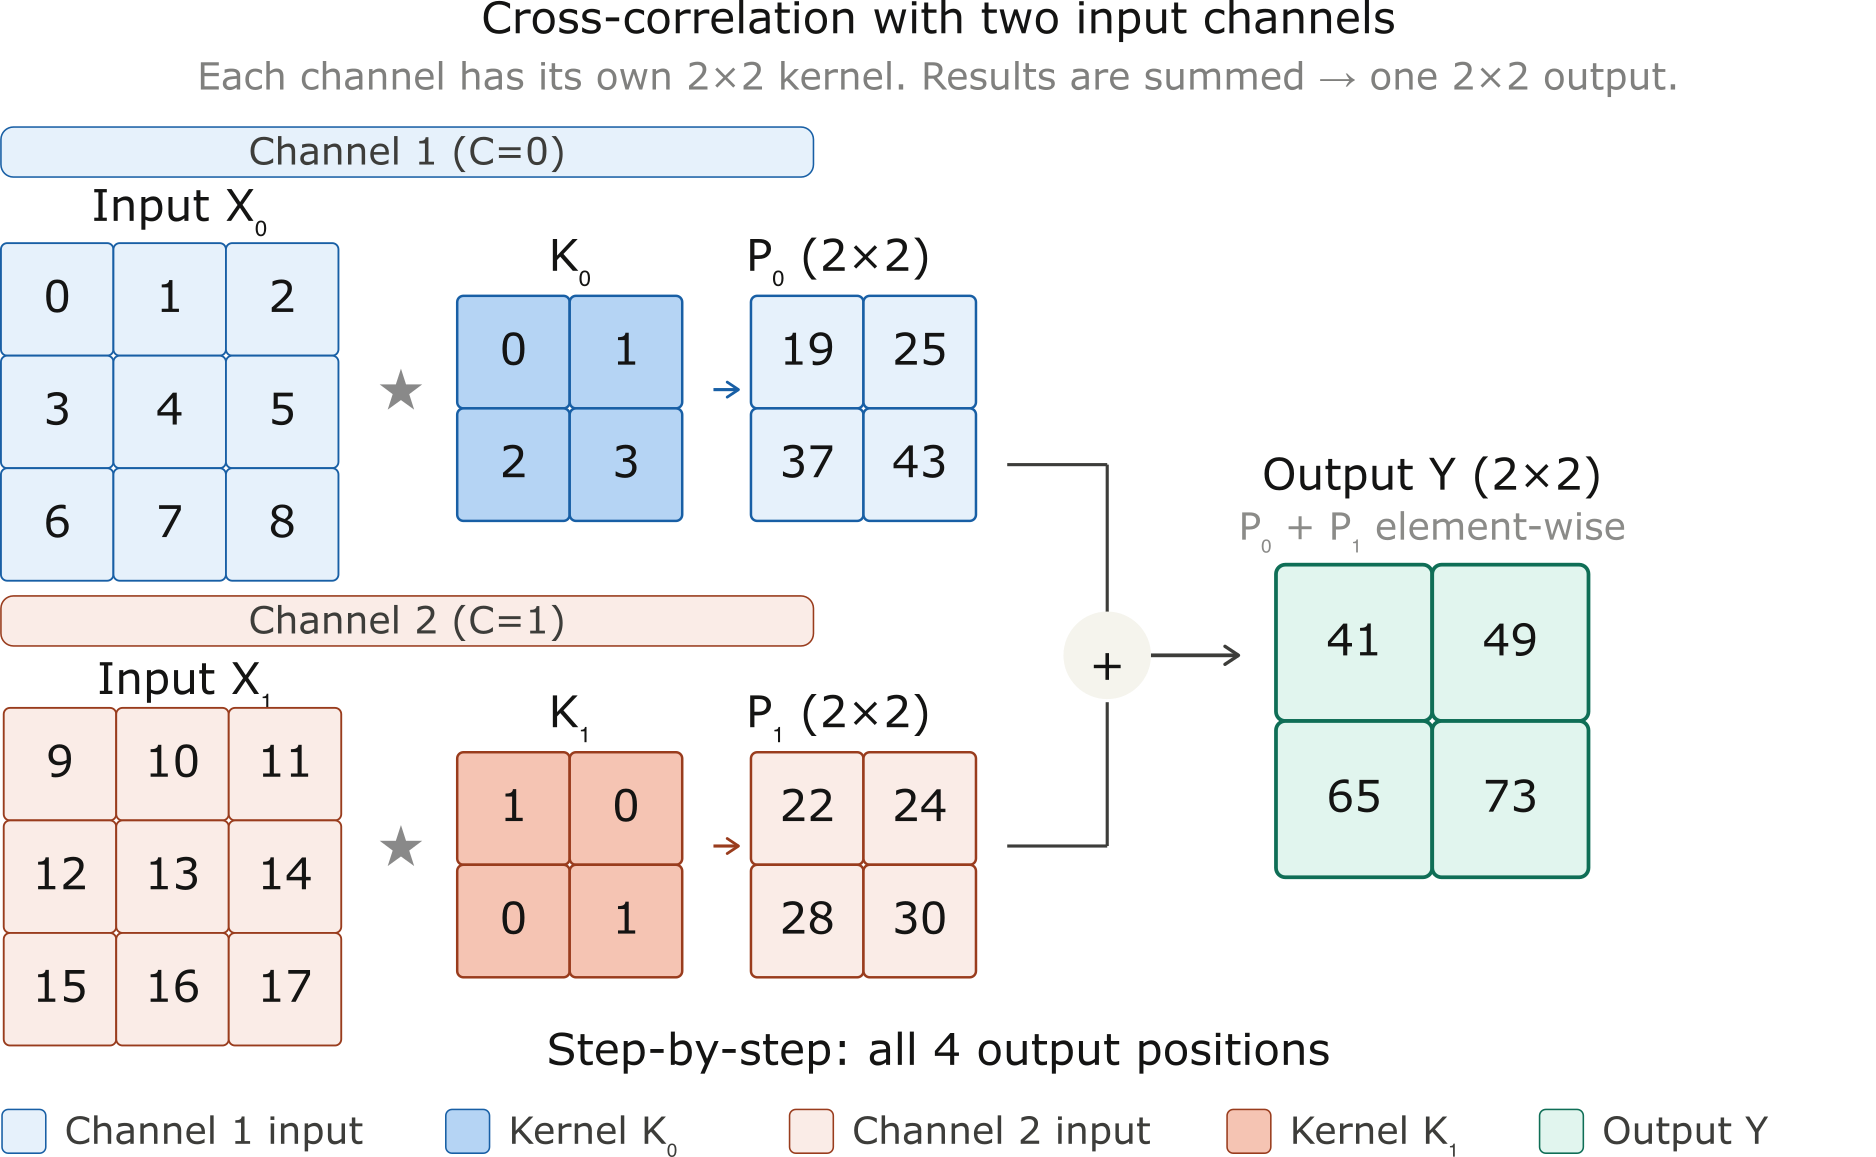

In [13]:
display(Image('./Fig/02_cross_correlation_two_input_channels.png', width=700))

In [54]:
def corr2d_multi_in(X, K):
    # Iterate through the 0th dimension (channel) of K first, then add them up
    return sum(corr2d(x, k) for x, k in zip(X, K))

In [55]:
X = torch.tensor([[[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]],
               [[9.0, 10.0, 11.0], [12.0, 13.0, 14.0], [15.0, 16.0, 17.0]]])
K = torch.tensor([[[0.0, 1.0], [2.0, 3.0]], [[1.0, 0.0], [0.0, 1.0]]])

corr2d_multi_in(X, K)

tensor([[41., 49.],
        [65., 73.]])

#### 2.5.2 Multiple output channels

In the most popular neural network architectures, actually the channel dimension is increased in order to go deeper in the neural network, also typically downsampled to trade off spatial resolution for greater channel depth.

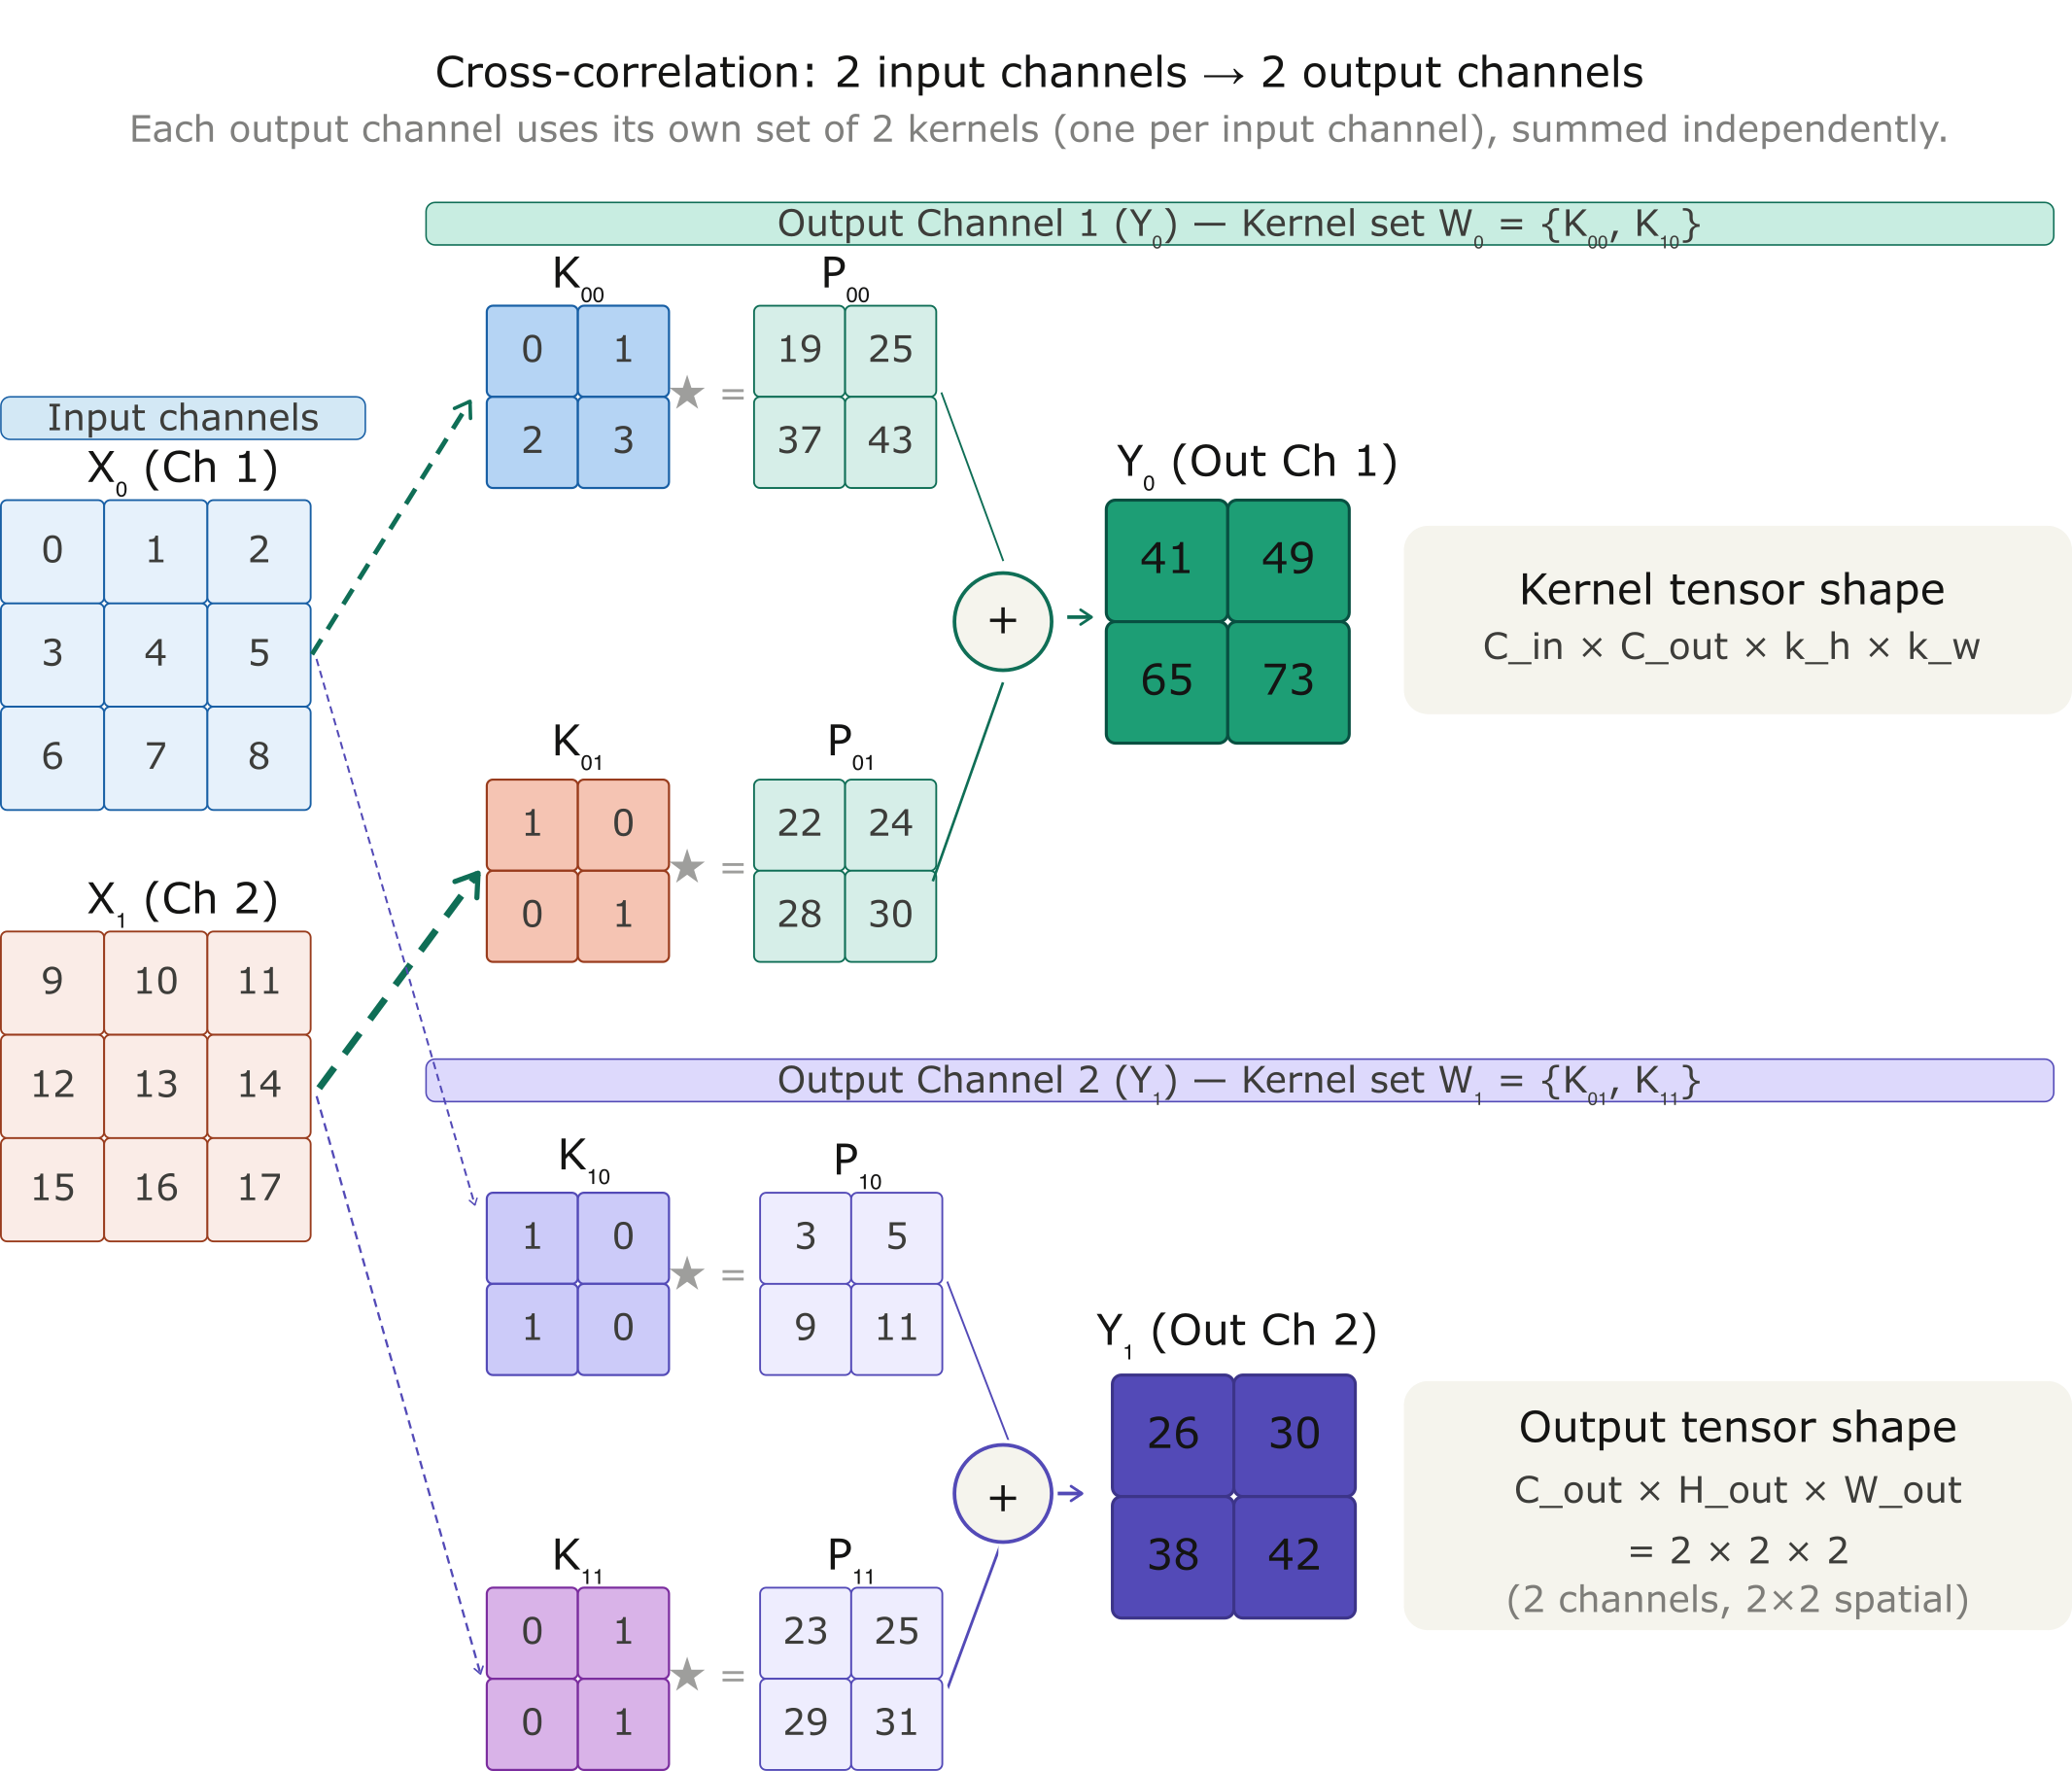

In [14]:
display(Image('./Fig/02_cross_correlation_2in_2out_channels2.png', width=700))

In [57]:
def corr2d_multi_in_out(X, K):
    # Iterate through the 0th dimension of K, and each time, perform
    # cross-correlation operations with input X. All of the results are
    # stacked together
    return torch.stack([corr2d_multi_in(X, k) for k in K], 0)

In [58]:
K_0 = torch.tensor([[[0.0, 1.0], [2.0, 3.0]], [[1.0, 0.0], [0.0, 1.0]]])
K_1 = torch.tensor([[[1.0, 0.0], [1.0, 0.0]], [[0.0, 1.0], [0.0, 1.0]]])
K_s = torch.stack((K_0, K_1), 0)
K_s.shape

torch.Size([2, 2, 2, 2])

In [59]:
K_s

tensor([[[[0., 1.],
          [2., 3.]],

         [[1., 0.],
          [0., 1.]]],


        [[[1., 0.],
          [1., 0.]],

         [[0., 1.],
          [0., 1.]]]])

In [60]:
corr2d_multi_in_out(X, K_s)

tensor([[[41., 49.],
         [65., 73.]],

        [[26., 30.],
         [38., 42.]]])

#### 2.5.3 Pooling in multiple channels

When processing multi-channel input data, the pooling layer pools each input channel separately

In [159]:
X_mul = torch.cat((X_ps, X_ps + 1), 1)
X_mul

tensor([[[[ 0.,  1.,  2.,  3.],
          [ 4.,  5.,  6.,  7.],
          [ 8.,  9., 10., 11.],
          [12., 13., 14., 15.]],

         [[ 1.,  2.,  3.,  4.],
          [ 5.,  6.,  7.,  8.],
          [ 9., 10., 11., 12.],
          [13., 14., 15., 16.]]]])

In [160]:
pool2d = nn.MaxPool2d(3, padding=1, stride=2)
pool2d(X_mul)

tensor([[[[ 5.,  7.],
          [13., 15.]],

         [[ 6.,  8.],
          [14., 16.]]]])

#### 2.5.4  $1 \times 1$ Convolutional Layer

$1 \times 1$ Convolutions are popular operations which are sometimes included in the designs of complex deep networks, e.g., ResNet. $1 \times 1$ Convolution allows:
- Channel dimensionality reduction,
- Cross-channel mixing
- Nonlinearity without spatial cost (Network-in-Network (2013))
- The bottleneck block: the pattern that made ResNet-50/101/152 practical

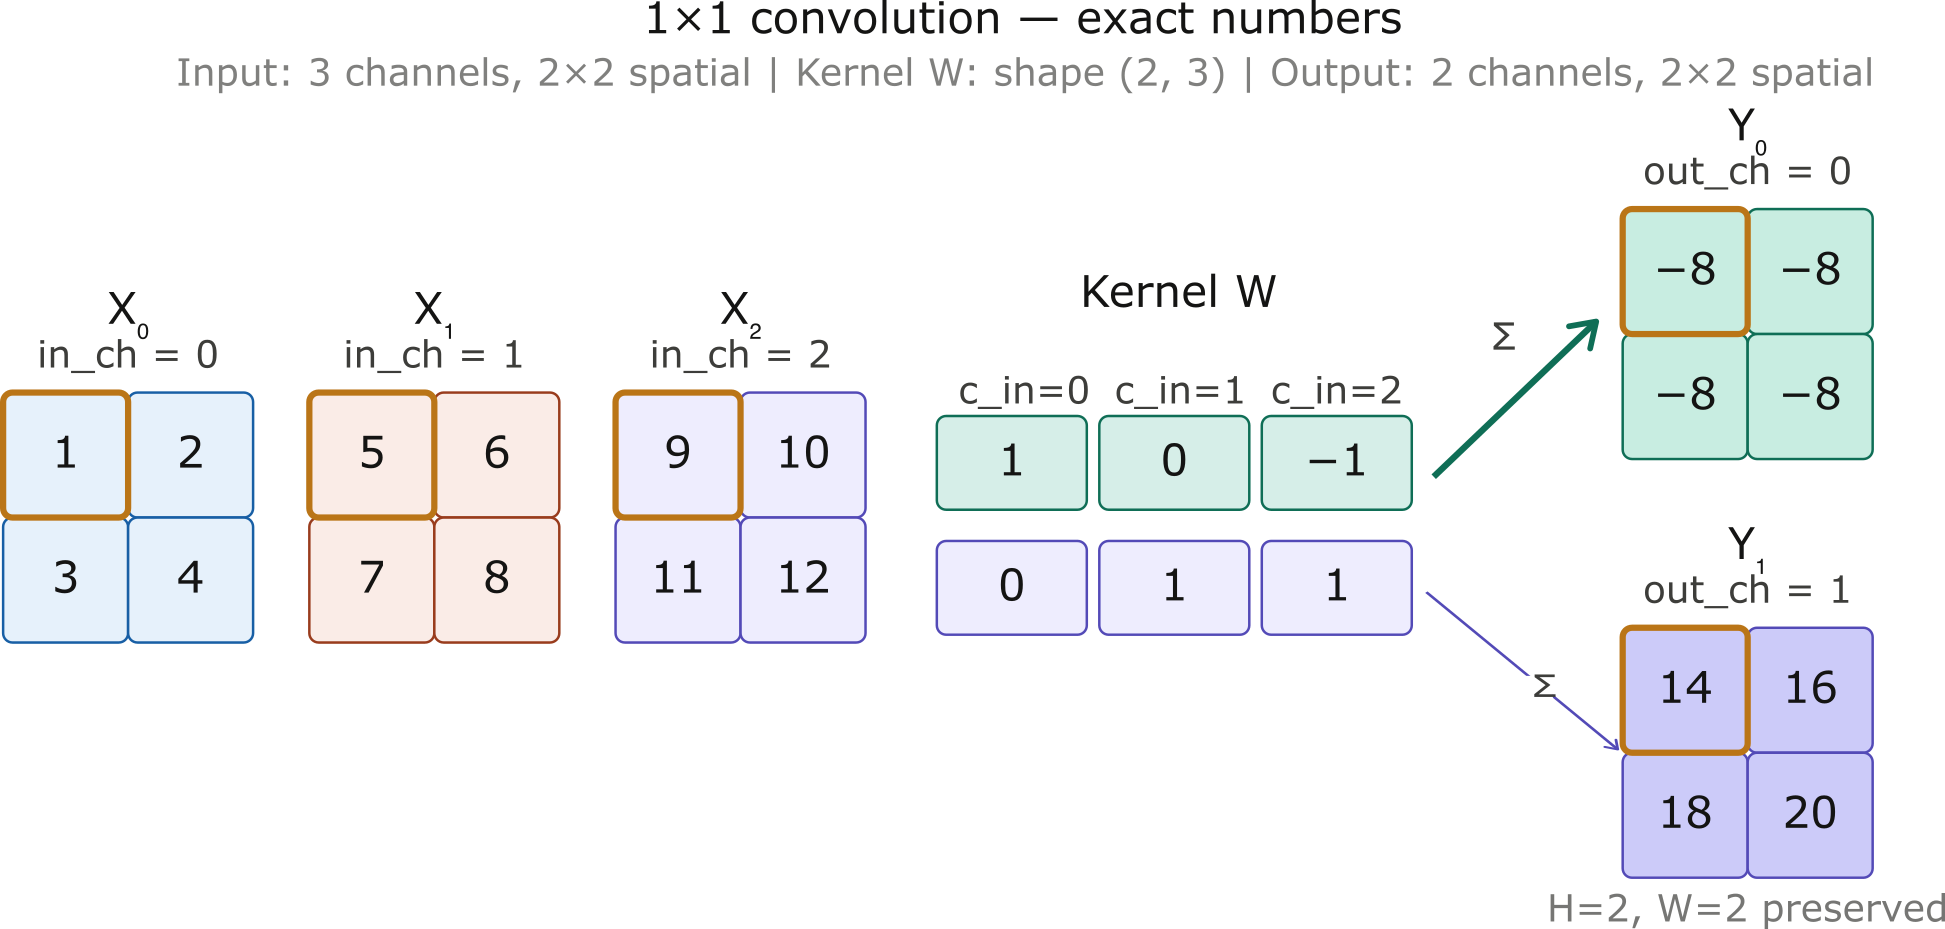

In [15]:
display(Image('./Fig/02_pointwise_conv_1x1_exact_numbers.png', width=700))

The inputs and outputs have the same height and width. And each element in the output is derived from a linear combination of elements at the same position in the input image. 

One could think of the $1 \times 1$ convolutional layer as constituting a fully connected layer applied at every single pixel location to transform the $c_{\mathrm{i}}$ corresponding input values into $c_{\mathrm{o}}$ output values.

In [62]:
X_11 = torch.tensor([[[1,2],[3,4]],[[5,6],[7,8]],[[9,10],[11,12]]])
K_11 = torch.tensor([[[[1]],[[0]],[[-1]]], [[[0]],[[1]],[[1]]]])

In [63]:
X_11.shape

torch.Size([3, 2, 2])

In [64]:
K_11.shape

torch.Size([2, 3, 1, 1])

In [65]:
def corr2d_multi_in_out_1x1(X, K):
    c_i, h, w = X.shape
    c_o = K.shape[0]
    X = X.reshape((c_i, h * w))
    K = K.reshape((c_o, c_i))
    # Matrix multiplication in the fully connected layer
    Y = torch.matmul(K, X)
    return Y.reshape((c_o, h, w))

In [66]:
Y1 = corr2d_multi_in_out_1x1(X_11, K_11)
Y2 = corr2d_multi_in_out(X_11, K_11)

In [67]:
assert float(torch.abs(Y1 - Y2).sum()) < 1e-6

In [68]:
Y1

tensor([[[-8, -8],
         [-8, -8]],

        [[14, 16],
         [18, 20]]])

In [69]:
Y2

tensor([[[-8., -8.],
         [-8., -8.]],

        [[14., 16.],
         [18., 20.]]])

### 2.6 Flatten layer

After the final convolutional and pooling layers, the 3D feature tensor [ $\mathrm{H} \times \mathrm{W} \times \mathrm{C}$ ] needs to be converted into a 1D vector before it can be passed to a fully connected layer for classification. This is what the flatten operation does - it simply unrolls all dimensions into a single vector of size $H \times W \times C$.

<img src="https://miro.medium.com/v2/resize:fit:720/format:webp/1*MMWlxjv0lCnd4dSkl81Cyw.jpeg" width="720">

In [168]:
# Simulate final feature tensor after conv + pooling
x = torch.randn(1, 8, 4, 4)
print("Before flatten:", x.shape)  # torch.Size([1, 8, 4, 4])

# Flatten all dimensions except batch
flatten = nn.Flatten()
x_flat = flatten(x)
print("After flatten: ", x_flat.shape)  # torch.Size([1, 128])

Before flatten: torch.Size([1, 8, 4, 4])
After flatten:  torch.Size([1, 128])


## 3. LeNet

LeNet is among the first published CNNs to capture wide attention for its performance on computer vision tasks. The model was introduced by (and named for) Yann LeCun. 

LeNet was adapted to recognize digits for processing deposits in ATM machines. To this day, some ATMs still run the code that Yann LeCun and his colleague Leon Bottou wrote in the 1990s!

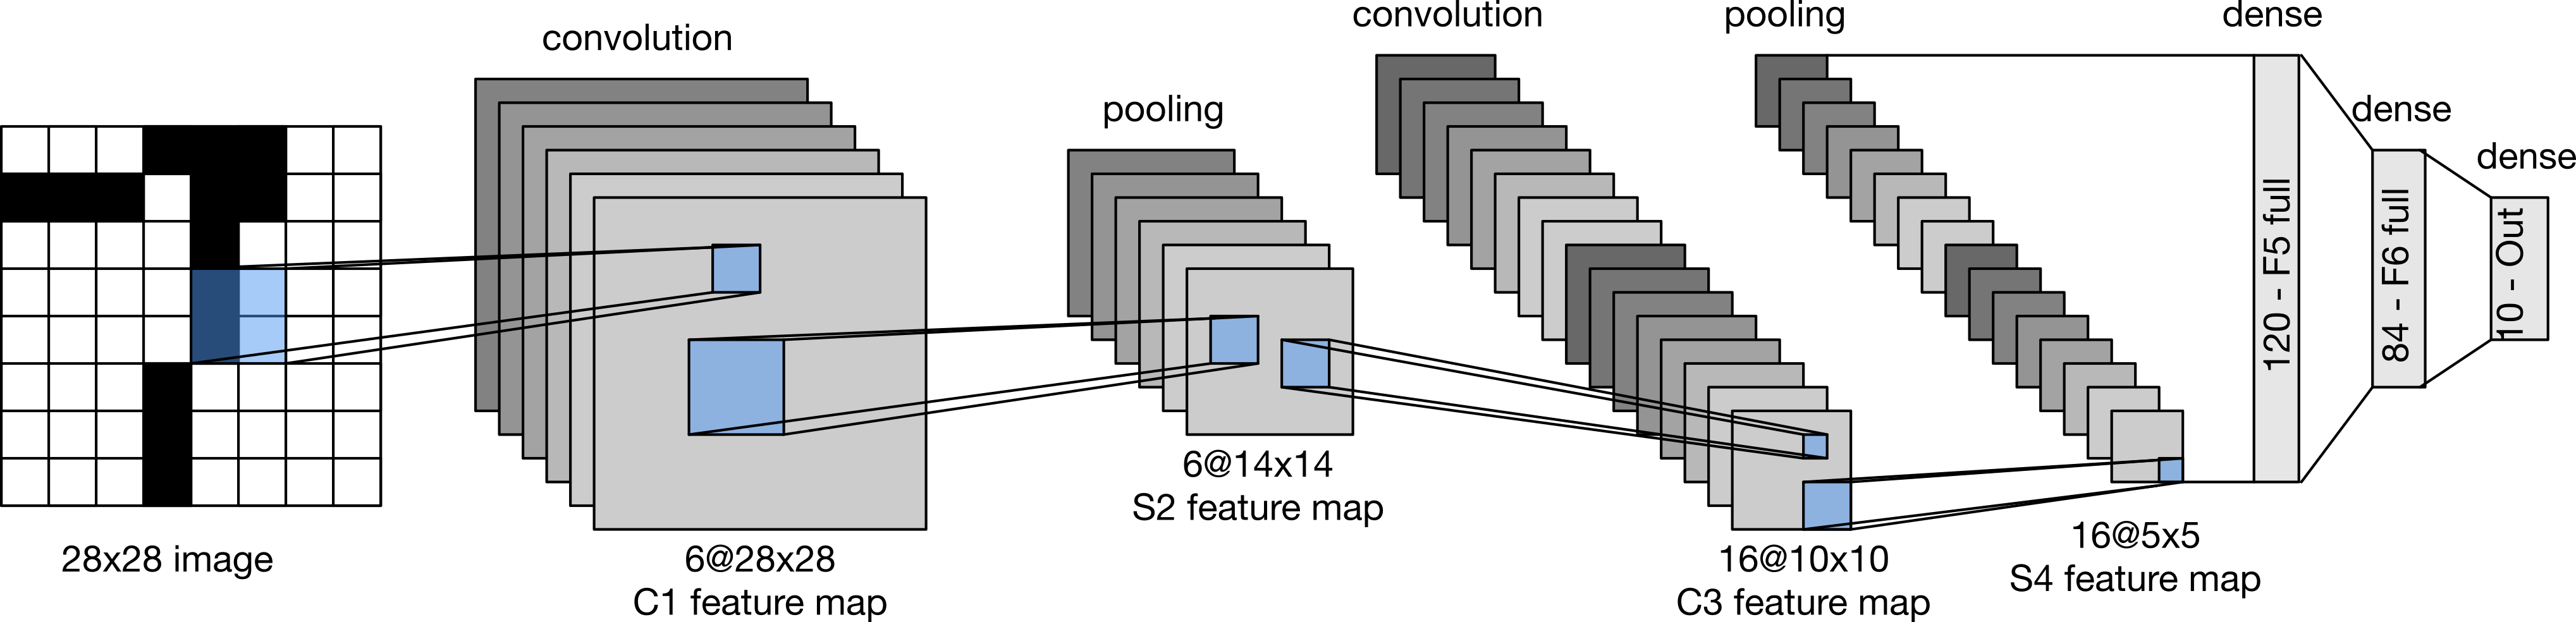

In [16]:
display(Image('./Fig/02_LeNet-5_architecture.png', width=900))

The basic units in each convolutional block are a convolutional layer, a sigmoid activation function, and a subsequent average pooling operation. While ReLUs and max-pooling work better, they had not yet been discovered!

The convolutional block emits an output with shape given by (batch size, number of channel, height, width).

Each example in the minibatch must be flattened to pass output from the convolutional block to the dense block. For classification, the 10-dimensional output layer corresponds to the number of possible output classes.

In [180]:
def init_cnn(module):
    """Initialize weights for CNNs."""
    if type(module) == nn.Linear or type(module) == nn.Conv2d:
        nn.init.xavier_uniform_(module.weight)


class LeNet(nn.Module):
    """The LeNet-5 model."""
    def __init__(self, lr=0.1, num_classes=10):
        super().__init__()
        self.lr = lr
        self.num_classes = num_classes
        self.net = nn.Sequential(
            nn.LazyConv2d(6, kernel_size=5, padding=2), nn.Sigmoid(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.LazyConv2d(16, kernel_size=5), nn.Sigmoid(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.LazyLinear(120), nn.Sigmoid(),
            nn.LazyLinear(84), nn.Sigmoid(),
            nn.LazyLinear(num_classes))

    def forward(self, X):
        return self.net(X)

For the function **init_cnn**:
```python
def init_cnn(module):
    """Initialize weights for CNNs."""
    if type(module) == nn.Linear or type(module) == nn.Conv2d:
        nn.init.xavier_uniform_(module.weight)
```

Note that here Xavier uniform initialization is used. 

Xavier uniform draws weights from a uniform distribution centered at zero, with bounds calculated to keep the variance of activations stable across layers. Specifically, for a layer with number of inputs *fan-in (inputs)* and number of outputs *fan-out (outputs)*, it samples from:

$U\left(-\sqrt{\frac{6}{fan-in+fan-out}}, \sqrt{\frac{6}{fan-in+fan-out}}\right)$

This ensures that as data flows forward through the network, the variance of hidden activations stays roughly constant, not exploding or vanishing.

<strong>💡 What if we just use random weights?</strong>

If we initilize with, for example, N(0,1) (standard normal), several problems arise:

1. Variance explosion - In early layers, if we have 1000 input features and initialize with large random values, the dot product of inputs × weights becomes huge. Activations explode. Gradients explode. Training fails.
2. Variance collapse - Or if we initialize too small, activations shrink layer-by-layer. Gradients vanish. The network "forgets" input information. Deep networks become untrainable.
3. Slow convergence - Without proper scaling, the optimizer spends iterations just recovering from bad initialization before actual learning begins.

In Xavier's initilization, by tuning the variance based on layer width, the signal flow is stabilized across the entire network from the first forward pass, which:

- Keeps hidden activations in a reasonable range
- Allows gradients to flow smoothly during backprop
- Enables faster, more stable training

In [181]:
def layer_summary(self, X_shape):
    X = torch.randn(*X_shape)
    for layer in self.net:
        X = layer(X)
        print(layer.__class__.__name__, 'output shape:\t', X.shape)

LeNet.layer_summary = layer_summary

model = LeNet()
model.layer_summary((1, 1, 28, 28))

Conv2d output shape:	 torch.Size([1, 6, 28, 28])
Sigmoid output shape:	 torch.Size([1, 6, 28, 28])
AvgPool2d output shape:	 torch.Size([1, 6, 14, 14])
Conv2d output shape:	 torch.Size([1, 16, 10, 10])
Sigmoid output shape:	 torch.Size([1, 16, 10, 10])
AvgPool2d output shape:	 torch.Size([1, 16, 5, 5])
Flatten output shape:	 torch.Size([1, 400])
Linear output shape:	 torch.Size([1, 120])
Sigmoid output shape:	 torch.Size([1, 120])
Linear output shape:	 torch.Size([1, 84])
Sigmoid output shape:	 torch.Size([1, 84])
Linear output shape:	 torch.Size([1, 10])


> Note that the height and width of the representation at each layer throughout the convolutional block is reduced.

## 4. Techniques for improving CNN performance and training stability

The trained CNN/LeNet might see training accuracy higher than validation
--> data cleaning; increasing data variety to help model generalize better 

### 4.1 Data transforms

Before training, raw images need to be prepared for the network. In PyTorch, all preprocessing and augmentation steps are defined together in a transforms.Compose pipeline: a sequential list of operations applied to every image. This section covers the three most common types: resize, normalization, and augmentation.

#### 4.1.1 Resize

Images in a dataset often come in different sizes. CNNs require a fixed input size, so resizing is almost always the first step.

In [191]:
import torchvision.transforms.functional as F
from PIL import Image

# Load image
img = Image.open("./Figs/Raw_scratch.png").convert('RGB')  # drops alpha channel
#img = Image.open("./Figs/Raw_scratch.png")

In [192]:
import torchvision.transforms as T

resize = T.Resize((28, 28))  # resize to 28×28 pixels
img_resized = resize(img)
print(img_resized.size)  # (28, 28)

(28, 28)


#### 4.1.2 Normalization

Raw pixel values range from 0 to 255 (or 0.0 to 1.0 after converting to float). Normalization rescales pixel values to have zero mean and unit variance, which stabilizes training by keeping activations in a consistent range.

In [195]:
# First convert PIL image to tensor (scales to [0.0, 1.0])
to_tensor = T.ToTensor()
img_tensor = to_tensor(img_resized)  # use resized image from previous step
print(img_tensor.shape)             
print(img_tensor.min(), img_tensor.max())  # tensor(0.) tensor(1.)

# Normalize with mean and std
# For grayscale: one value each; for RGB: one value per channel
normalize = T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
img_normalized = normalize(img_tensor)
print(img_normalized.min(), img_normalized.max())  # tensor(-1.) tensor(1.)

torch.Size([3, 28, 28])
tensor(0.3333) tensor(0.8784)
tensor(-0.3333) tensor(0.7569)


The choice of mean and standard deviation in **T.Normalize** depends on the use case. Here we use [0.5, 0.5, 0.5] for both, which is a simple default that centers pixel values in the range [-1, 1] and works well for teaching and quick experiments. 

In practice, when fine-tuning a pretrained model that was originally trained on ImageNet for example, you should use the ImageNet statistics (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), which were computed from the actual ImageNet training set. Using different values would degrade transfer learning performance. For custom datasets trained from scratch, the correct approach is to compute mean and standard deviation directly from your own training set.

#### 4.1.3 Data augmentation

Augmentation artificially increases the diversity of the training set by applying random transformations to each image during training. This reduces overfitting and improves generalization.

In [196]:
# 1. Horizontal flip
flipped_h = F.hflip(img)

# 2. Vertical flip
flipped_v = F.vflip(img)

# 3. Rotation
rotated = F.rotate(img, angle=30)

# 4. Zoom (crop center then resize back)
w, h = img.size
cropped = F.center_crop(img, output_size=[int(h*0.7), int(w*0.7)])
zoomed  = F.resize(cropped, [h, w])

# 5. Width shift (affine translate)
width_shifted = F.affine(img, angle=0, translate=[int(w*0.2), 0], scale=1.0, shear=0)

# 6. Height shift
height_shifted = F.affine(img, angle=0, translate=[0, int(h*0.2)], scale=1.0, shear=0)

# 7. Homography (perspective warp)
startpoints = [[0,0], [w,0], [w,h], [0,h]]
endpoints   = [[int(w*0.1),0], [int(w*0.9),0], [w,h], [0,h]]
homography  = F.perspective(img, startpoints, endpoints)

# 8. Brightness
brightened = F.adjust_brightness(img, brightness_factor=1.8)

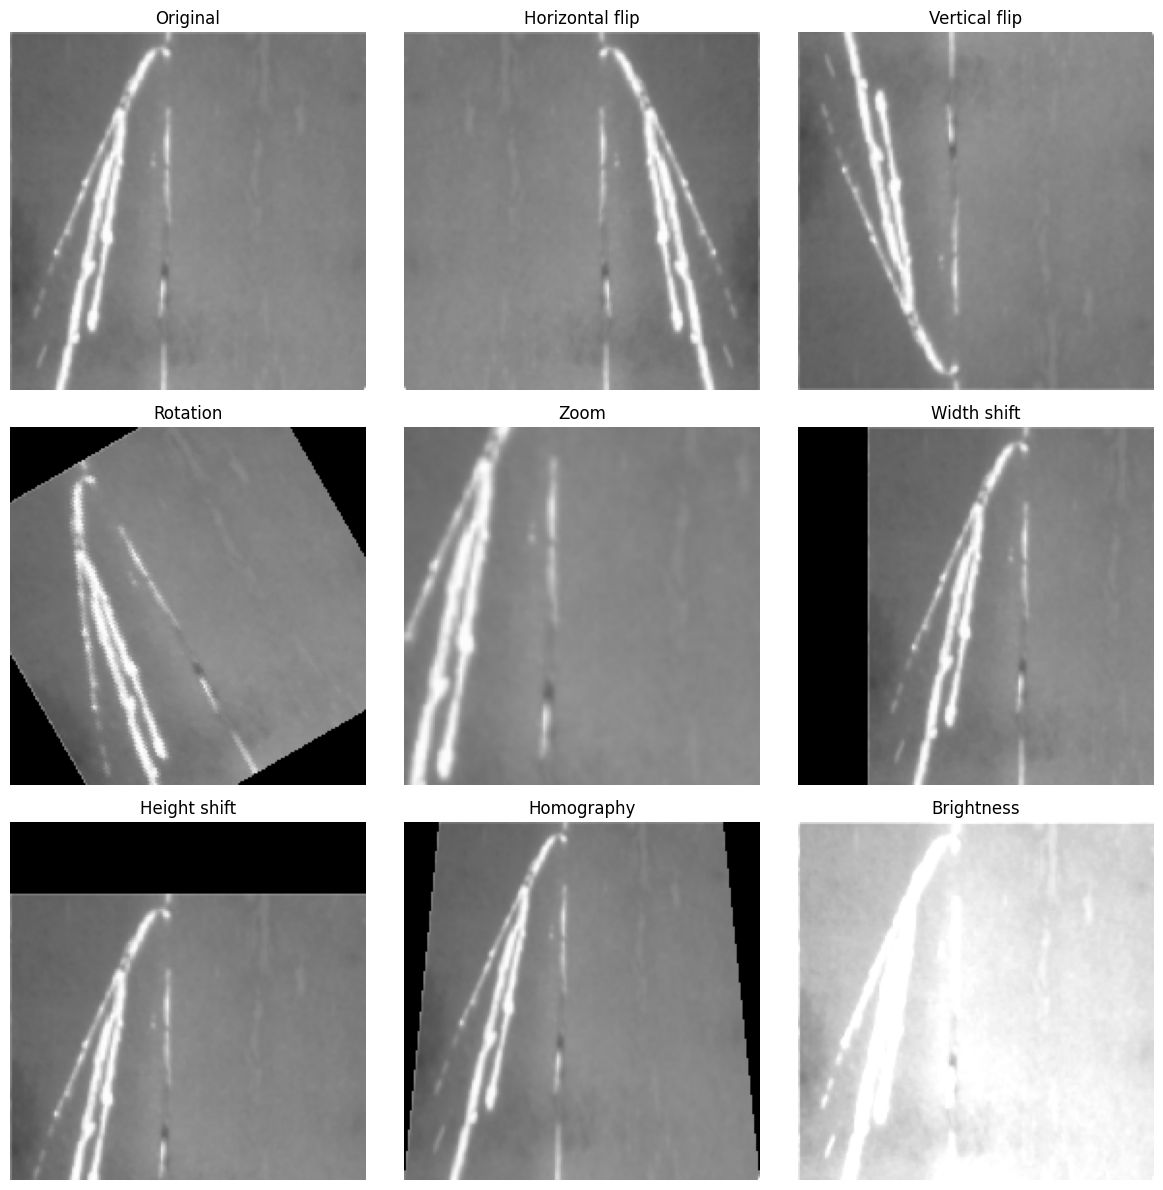

In [197]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

images = [img, flipped_h, flipped_v, rotated, zoomed, width_shifted, height_shifted, homography, brightened]
titles = ['Original', 'Horizontal flip', 'Vertical flip', 'Rotation',
          'Zoom', 'Width shift', 'Height shift', 'Homography', 'Brightness']

for ax, image, title in zip(axes, images, titles):
    if hasattr(image, 'permute'):  # PyTorch tensor
        ax.imshow(image.permute(1, 2, 0))
    else:  # PIL image
        ax.imshow(image)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

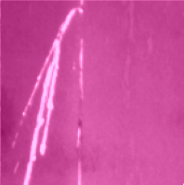

In [198]:
# 9. Channel shift — adjust each channel independently via color jitter
from torchvision.transforms import ColorJitter
#For colored image
#channel_shifted = ColorJitter(brightness=0, contrast=0, saturation=0, hue=0.3)(img)

# Since the original image is grey, we first convert grayscale to RGB so channels can be shifted independently
img_rgb = img.convert("RGB")
img_tensor = F.to_tensor(img_rgb)  # shape: [3, H, W], values in [0, 1]

# Shift each channel by a different offset
r_shift, g_shift, b_shift = 0.3, -0.2, 0.1

channel_shifted_tensor = img_tensor.clone()
channel_shifted_tensor[0] = (img_tensor[0] + r_shift).clamp(0, 1)  # Red
channel_shifted_tensor[1] = (img_tensor[1] + g_shift).clamp(0, 1)  # Green
channel_shifted_tensor[2] = (img_tensor[2] + b_shift).clamp(0, 1)  # Blue

channel_shifted = F.to_pil_image(channel_shifted_tensor)
channel_shifted

### 4.2 Activation function

Without a non-linear activation after each convolutional layer, stacking multiple layers would collapse into a single linear operation, losing all representational power.

As seen in the LeNet implementation in Section 3, the original architecture used **Sigmoid** activations. However, modern CNNs almost exclusively use **ReLU** and its variants instead, for a simple reason: Sigmoid saturates at both ends (outputs near 0 or 1), causing gradients to vanish during backpropagation through deep networks. ReLU avoids this by keeping gradients alive for positive activations.

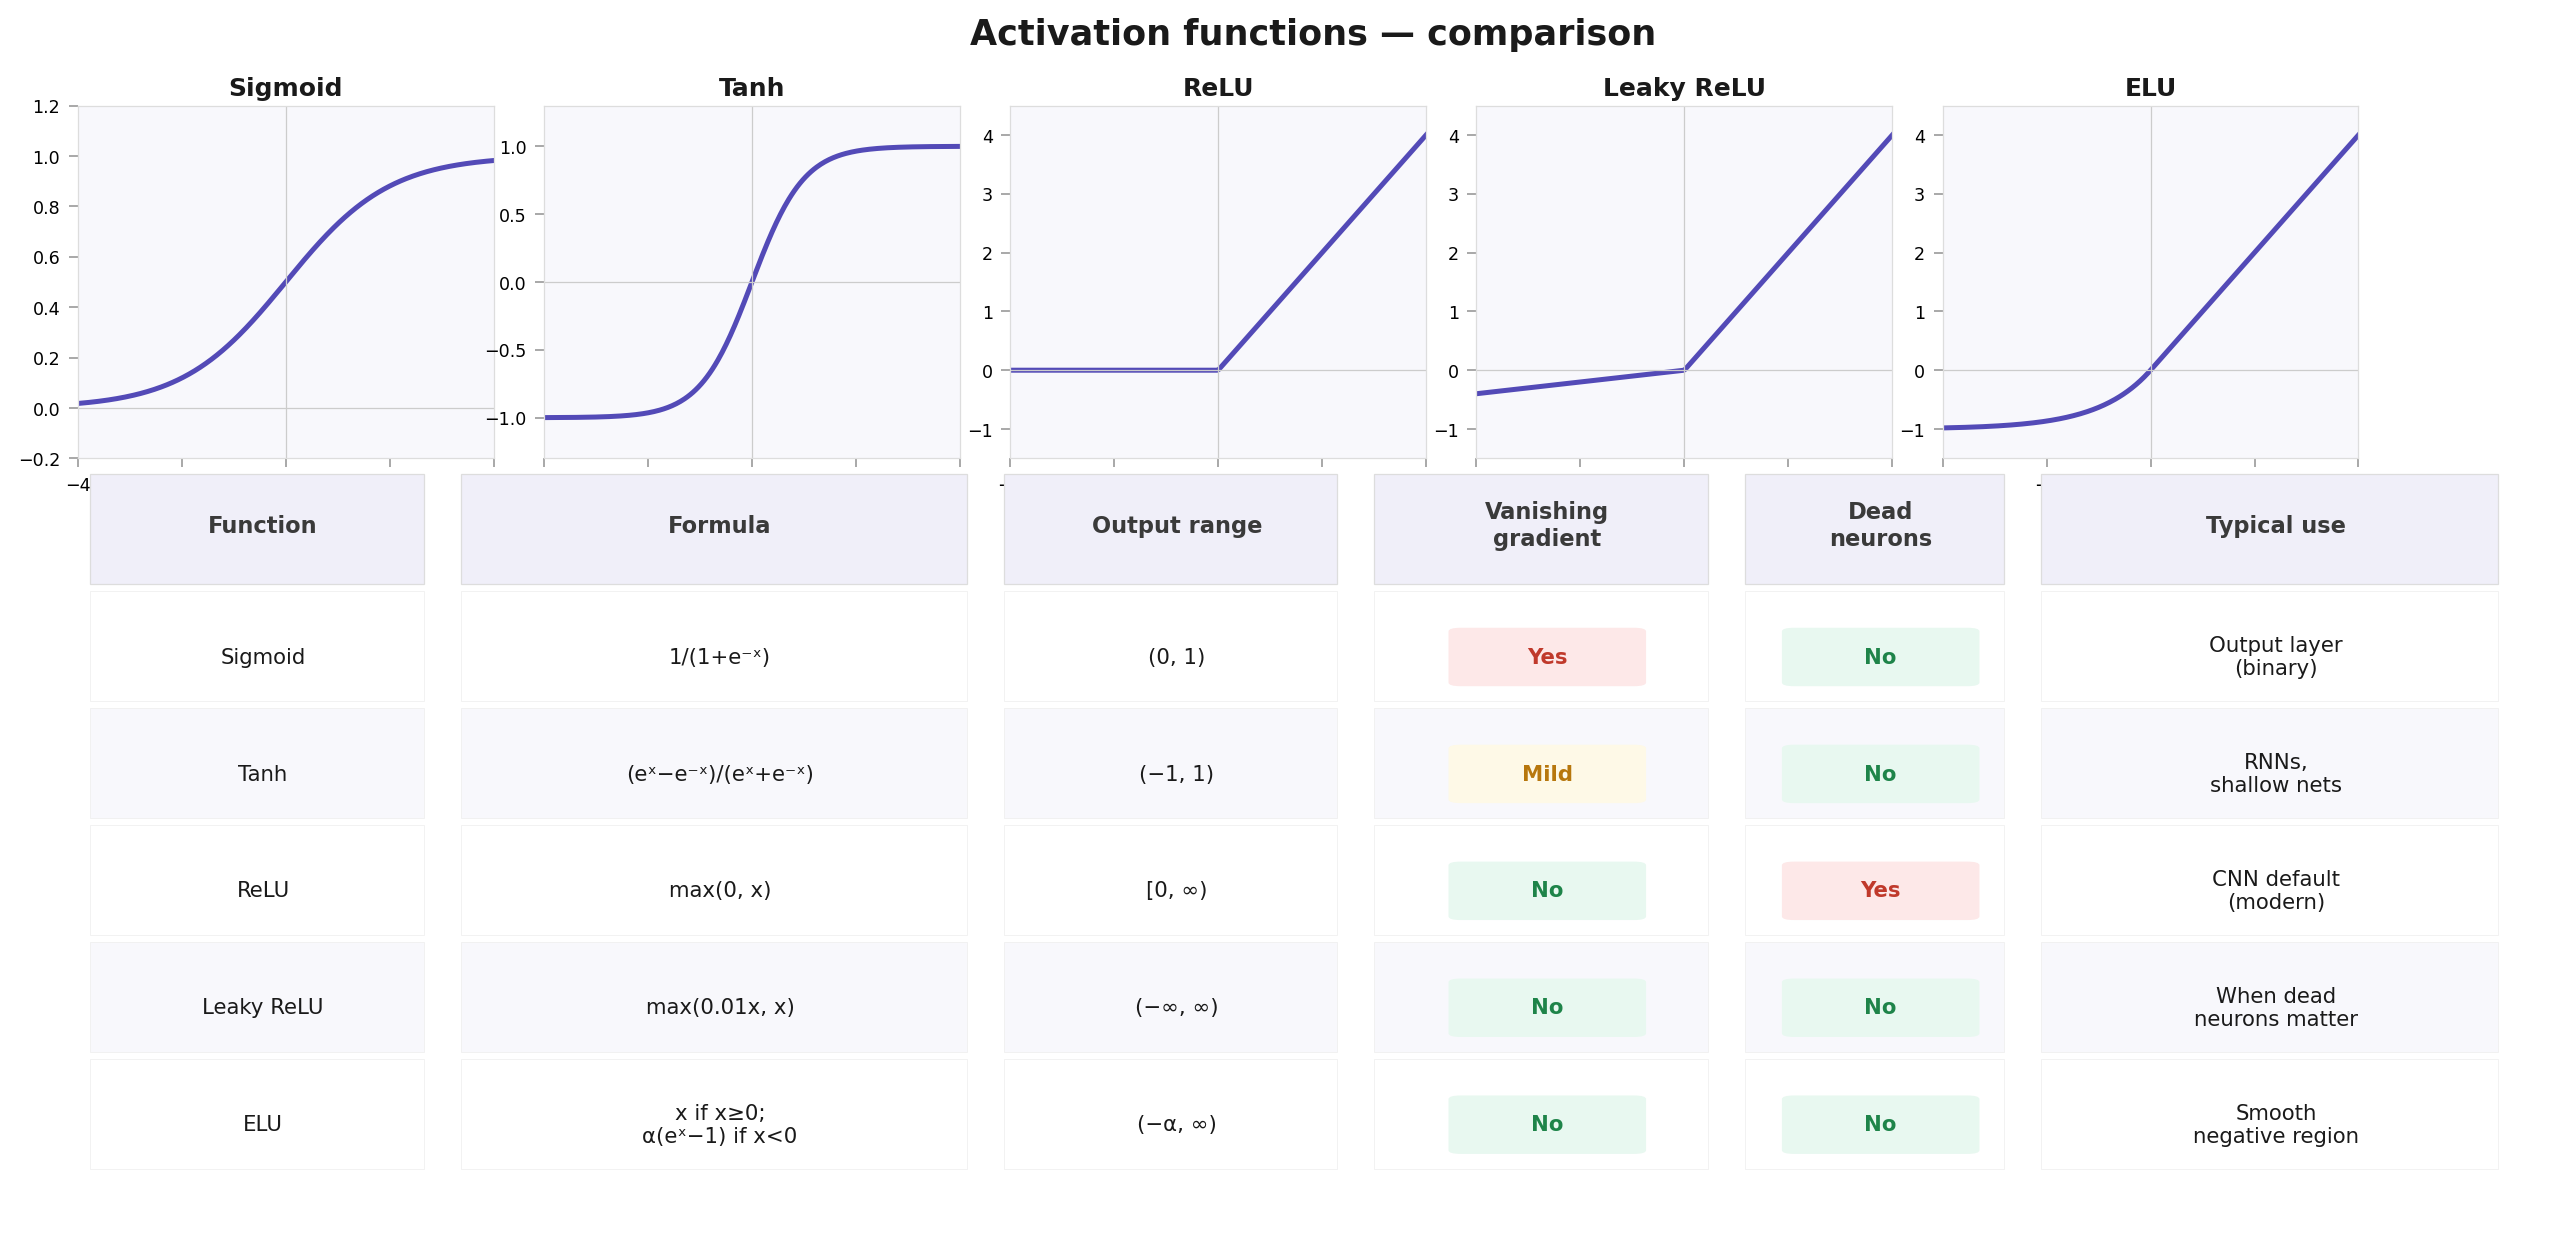

In [17]:
display(Image('./Fig/02_activation_functions_comparison.png', width=1000))

For most CNN applications today, ReLU is the default choice. Variants such as LeakyReLU or ELU are worth knowing but rarely change results dramatically in practice.

### 4.3 Dropout

Dropout did not exist when LeNet was designed in 1998. It was introduced by Hinton's group in 2012 and was notably used in AlexNet — the architecture that dramatically outperformed existing methods on ImageNet that same year. Along with ReLU activations and GPU training, dropout was one of several key ingredients that made AlexNet so successful.

**From LeNet(left) to AlexNet(right)**

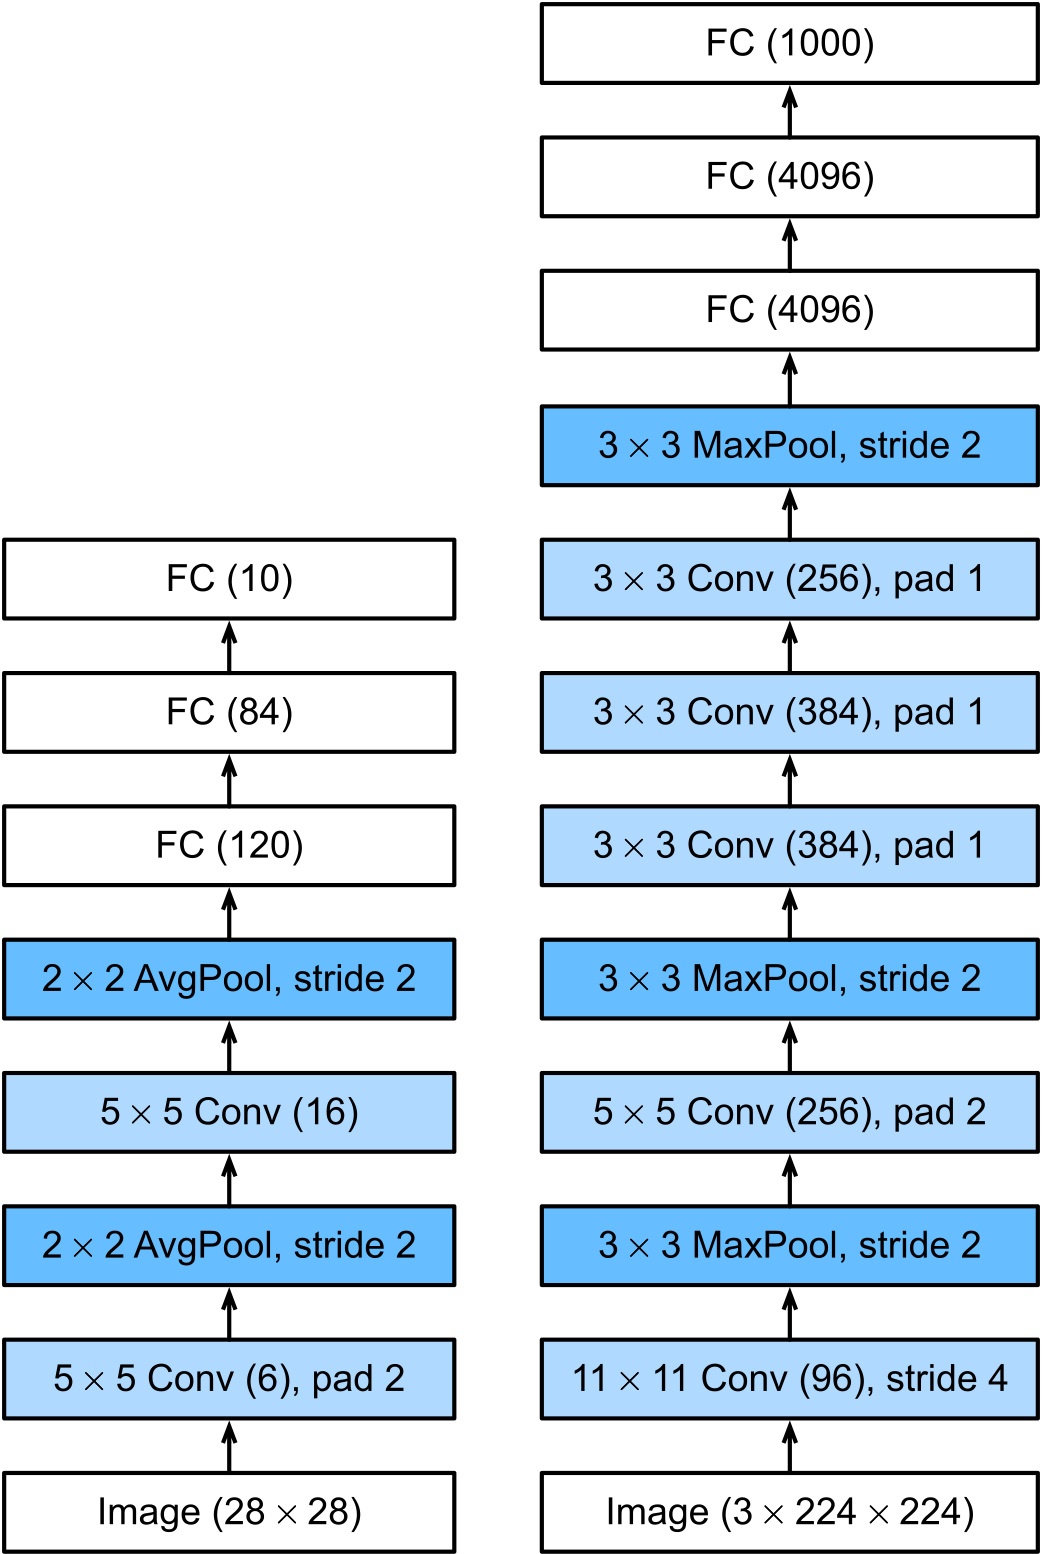

In [18]:
display(Image('./Fig/02_alexnet.png', width=500))

**What is dropout and why?**

We want a predictive model that performs well on unseen data — that is, we want to avoid overfitting.

The work of Bishop (Neural Computation, 7(1), 108–116, 1995) drew a clear mathematical connection between the requirement that a function be smooth (and thus simple), and the requirement that it be resilient to perturbations in the input. In other words, if a model is robust to noise in its inputs, it is less likely to overfit.

Building on this idea, Srivastava et al. (Journal of Machine Learning Research, 15(1), 1929–1958, 2014) extended it to the internal layers of a network, introducing dropout. 

Rather than adding noise to the inputs, dropout injects noise during forward propagation by randomly deactivating neurons at each layer during training. The name is straightforward: we literally drop out some neurons during each forward pass.

The key question is how to inject noise in a principled way. In standard dropout, each neuron in a layer is independently zeroed out with probability $p$ during training. To ensure the expected value of each layer's output remains unchanged, the surviving activations are scaled up by $\frac{1}{1-p}-$ compensating for the neurons that were dropped. 

Formally, with dropout probability $p$, each intermediate activation $h$ is replaced by a random variable $h^{\prime}$ as follows:

$$
h^{\prime}= \begin{cases}0 & \text { with probability } p \\ \frac{h}{1-p} & \text { otherwise }\end{cases}
$$

In [1]:
import torch.nn as nn

class AlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.LazyConv2d(96, kernel_size=11, stride=4, padding=1),
            nn.ReLU(), nn.MaxPool2d(kernel_size=3, stride=2),
            nn.LazyConv2d(256, kernel_size=5, padding=2), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.LazyConv2d(384, kernel_size=3, padding=1), nn.ReLU(),
            nn.LazyConv2d(384, kernel_size=3, padding=1), nn.ReLU(),
            nn.LazyConv2d(256, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2), nn.Flatten(),
            nn.LazyLinear(4096), nn.ReLU(), nn.Dropout(p=0.5),
            nn.LazyLinear(4096), nn.ReLU(), nn.Dropout(p=0.5),
            nn.LazyLinear(num_classes))
    def forward(self, x):
        return self.net(x)


In [5]:
import torch
from torchinfo import summary

model = AlexNet()
_ = model(torch.zeros(1, 1, 224, 224))  # materialize lazy layers

# --- Conv layer table ---
print(f"{'Layer':<15s} {'Filters':<8s} {'Kernel':<12s} {'Stride':<12s} {'Padding':<12s}")
print("-" * 65)
for name, layer in model.named_modules():
    if isinstance(layer, nn.Conv2d):
        print(
            f"{name:<15s} "
            f"{layer.out_channels:<8d} "
            f"{str(layer.kernel_size):<12s} "
            f"{str(layer.stride):<12s} "
            f"{str(layer.padding):<12s}"
        )

Layer           Filters  Kernel       Stride       Padding     
-----------------------------------------------------------------
net.0           96       (11, 11)     (4, 4)       (1, 1)      
net.3           256      (5, 5)       (1, 1)       (2, 2)      
net.6           384      (3, 3)       (1, 1)       (1, 1)      
net.8           384      (3, 3)       (1, 1)       (1, 1)      
net.10          256      (3, 3)       (1, 1)       (1, 1)      


In [6]:
# --- torchinfo summary ---
summary(
    model,
    input_size=(1, 1, 224, 224),
    depth=10,
    col_names=["input_size", "output_size", "kernel_size", "num_params"]
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Kernel Shape              Param #
AlexNet                                  [1, 1, 224, 224]          [1, 10]                   --                        --
├─Sequential: 1-1                        [1, 1, 224, 224]          [1, 10]                   --                        --
│    └─Conv2d: 2-1                       [1, 1, 224, 224]          [1, 96, 54, 54]           [11, 11]                  11,712
│    └─ReLU: 2-2                         [1, 96, 54, 54]           [1, 96, 54, 54]           --                        --
│    └─MaxPool2d: 2-3                    [1, 96, 54, 54]           [1, 96, 26, 26]           3                         --
│    └─Conv2d: 2-4                       [1, 96, 26, 26]           [1, 256, 26, 26]          [5, 5]                    614,656
│    └─ReLU: 2-5                         [1, 256, 26, 26]          [1, 256, 26, 26]          --                        --
│    └─Max

> Note that dropout is only used during training

<div style="background-color:#f0f4ff; border-left:5px solid #4a6fa5; padding:16px 20px; border-radius:6px; margin:16px 0; max-width:90%;">
<strong>💡 Looking ahead — Episode 3</strong>
<p>AlexNet marks the starting point of the modern deep CNN era. <a href="../3-TL-VGG-ResNet-ViT-lesson/">Episode 3 (Transfer Learning — VGG, ResNet, ViT)</a> picks up from here: VGG refined AlexNet's design by replacing large kernels with stacked 3×3 filters; ResNet solved the vanishing gradient problem that limits how deep AlexNet-style stacking can go; and all three architectures can be reused via transfer learning for steel defect classification without training from scratch.</p>
</div>

### 4.4 Batch normalization

Training a deep neural network is difficult, especially for getting them converged in a reasonable amount of time. Batch normalization is a popular and effective technique that consistently accelerates the convergence of deep networks. 

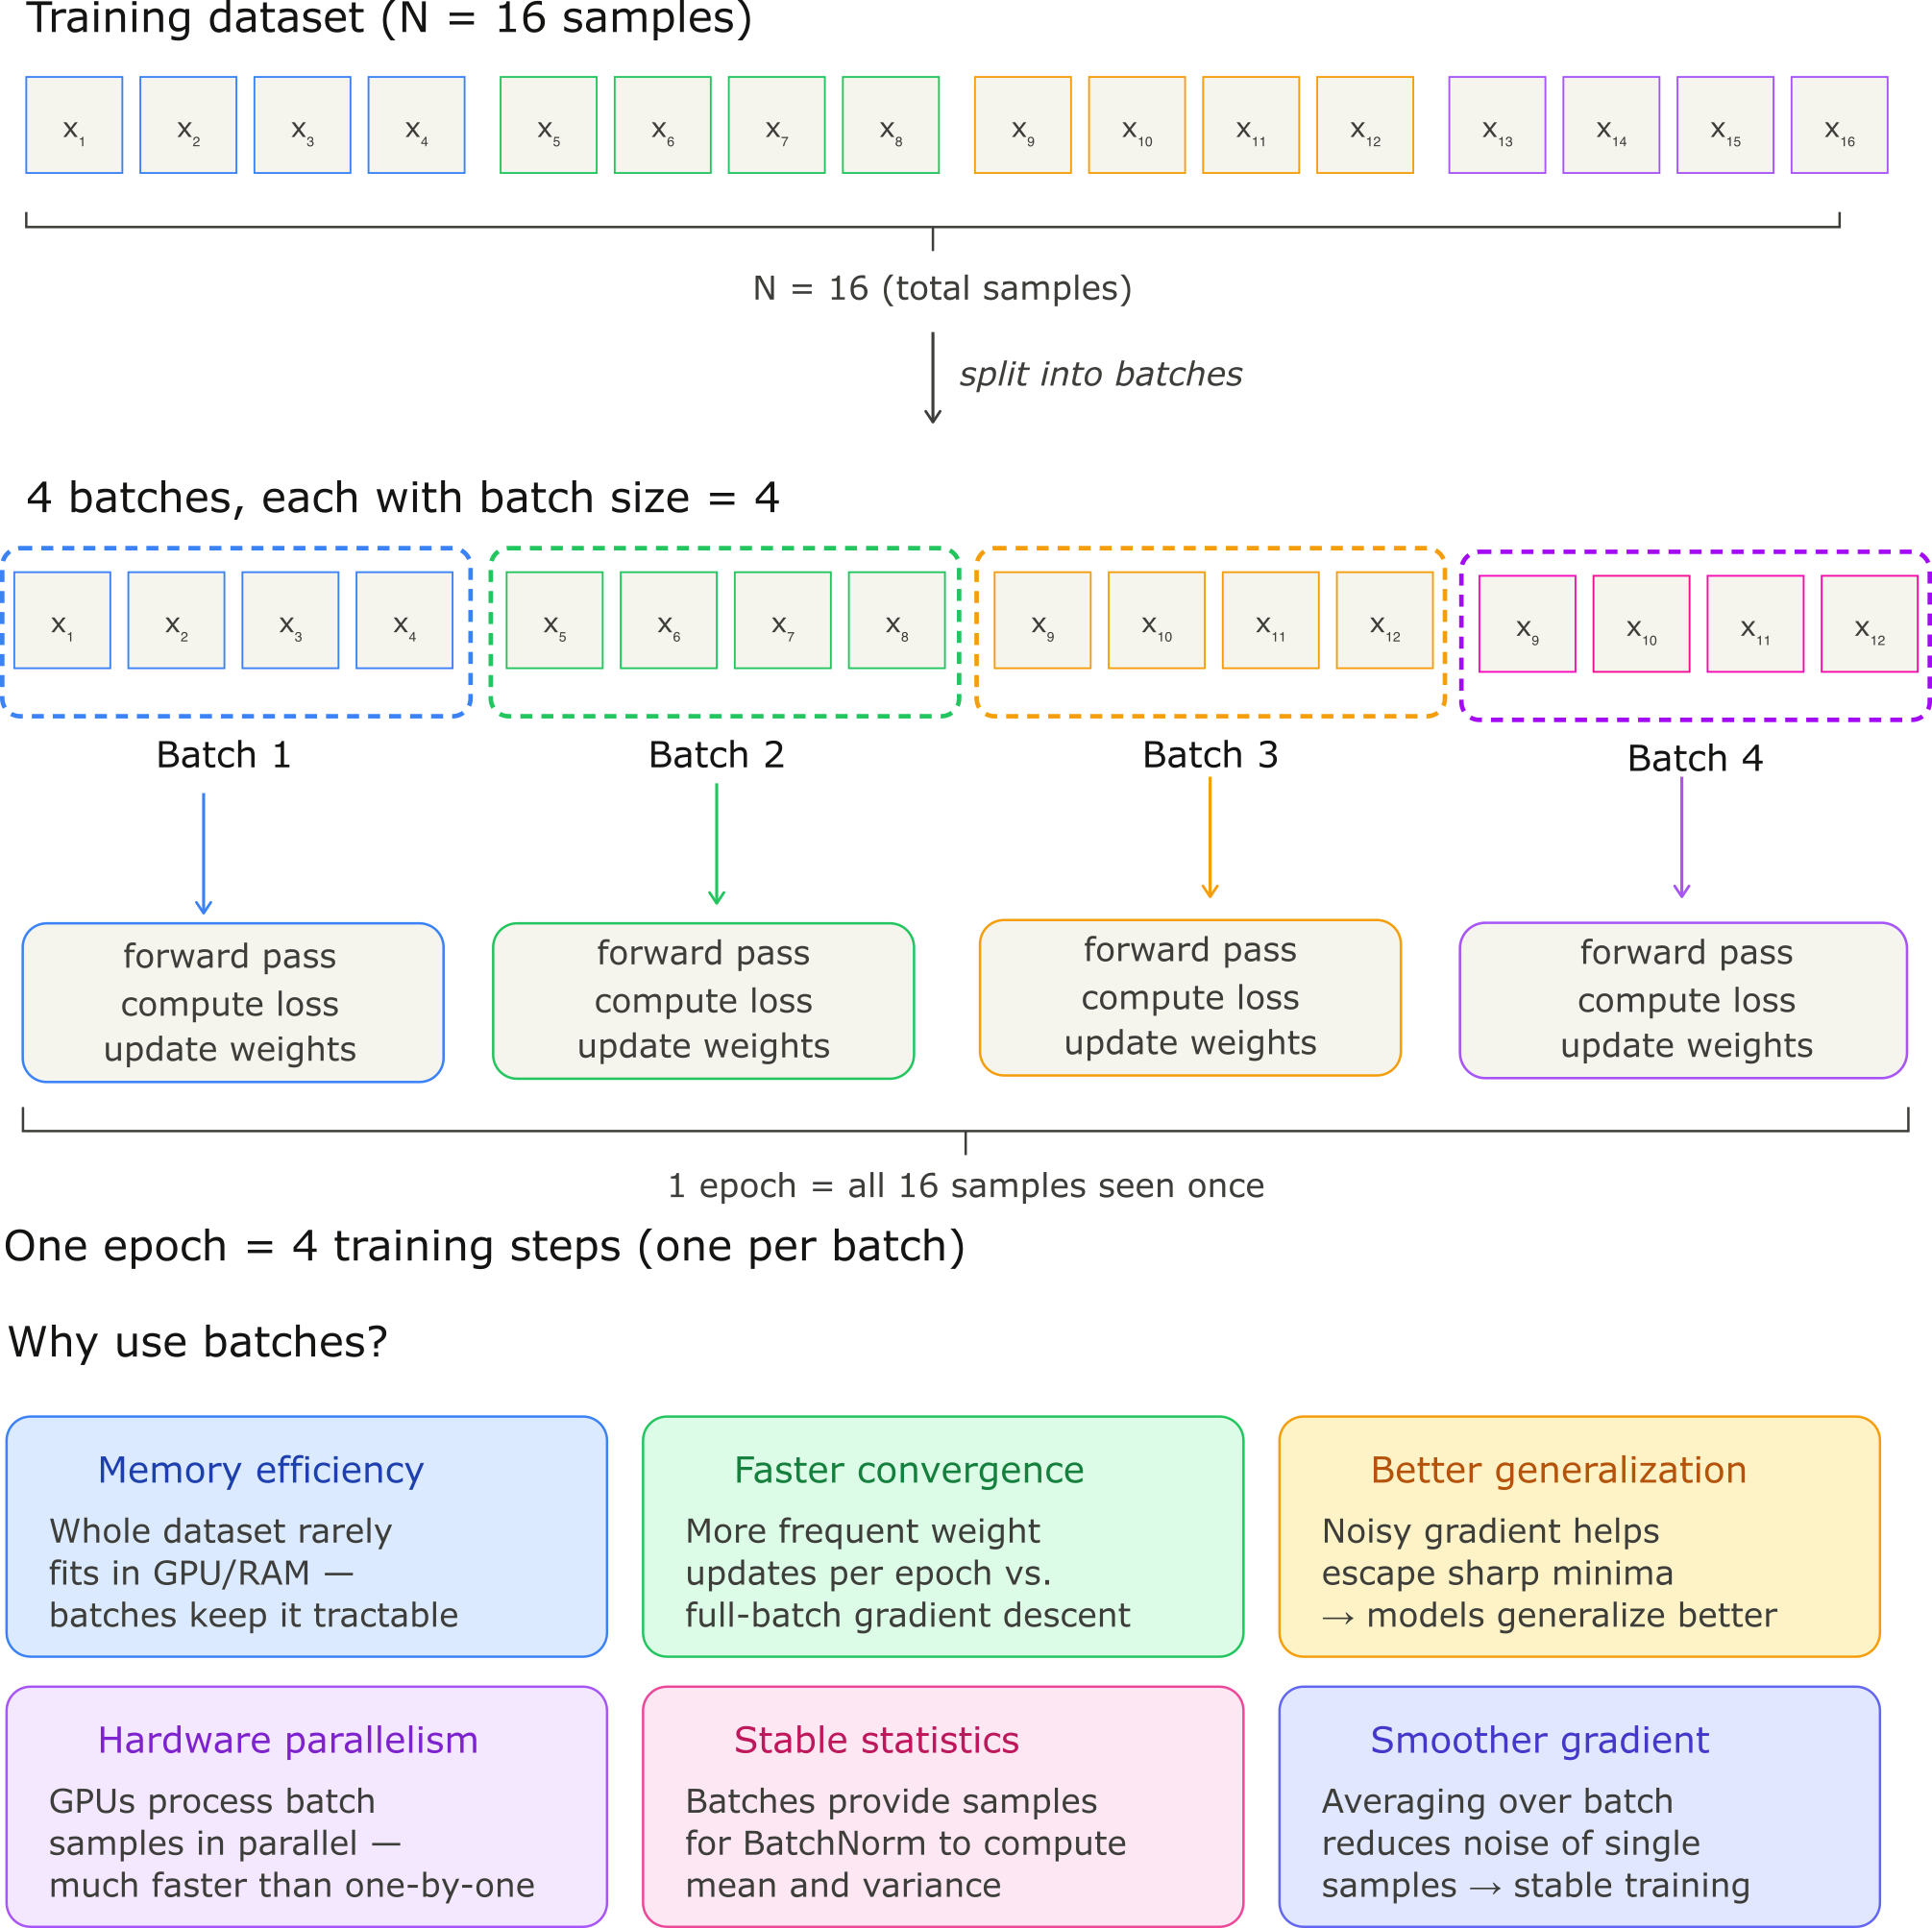

In [19]:
display(Image('./Fig/02_batch_and_batch_size_with_reasons.png', width=800))

**What is batch normalization?**

Batch normalization conveys three main benefits:
1. preprocessing: normalization step inside a deep network
2. numerical stability: convergence issue of the network caused by drift in the distribution of variables in intermediate layers
3. regularization: regularization by noise injection to prevent overfitting

Denote by $\mathcal{B}$ a minibatch and let $\mathbf{x} \in \mathcal{B}$ be an input to batch normalization $(\mathrm{BN})$. In this case the batch normalization is defined as follows:

$$
\mathrm{BN}(\mathbf{x})=\boldsymbol{\gamma} \odot \frac{\mathbf{x}-\hat{\boldsymbol{\mu}}_{\mathcal{B}}}{\hat{\boldsymbol{\sigma}}_{\mathcal{B}}}+\boldsymbol{\beta},
$$

where $\hat{\boldsymbol{\mu}}_{\mathcal{B}}$ is the sample mean and $\hat{\boldsymbol{\sigma}}_{\mathcal{B}}$ is the sample standard deviation of the minibatch $\mathcal{B}$. The resulting minibatch has zero mean and unit variance after standardization. Such choice is random, and the freedom of choice is recovered by the scale parameter $\gamma$ and shift parameter $\beta$. Both parameters are learnable during training. 

In addition, the batch normalization actively centers and rescales the variable magnitudes back to a given mean and size, so that the variable magnitudes for intermediate layers do not diverge during training.

$$ 
\hat{\boldsymbol{\mu}}_{\mathcal{B}}=\frac{1}{|\mathcal{B}|} \sum_{\mathbf{x} \in \mathcal{B}} \mathbf{x} ~and~
\hat{\boldsymbol{\sigma}}_{\mathcal{B}}^2=\frac{1}{|\mathcal{B}|} \sum_{\mathbf{x} \in \mathcal{B}}\left(\mathbf{x}-\hat{\boldsymbol{\mu}}_{\mathcal{B}}\right)^2+\epsilon
$$

A small constant $\epsilon>0$ is added to make sure we do not do devision on zero. The estimates $\hat{\boldsymbol{\mu}}_{\mathcal{B}}$ and $\hat{\boldsymbol{\sigma}}_{\mathcal{B}}$ counteract the scaling issue by using noisy estimates of mean and variance. And it turns out that various sources of noise in optimization often lead to faster training and less overfitting. As a matter fact, this is still a scientific question to which we have not really found out solid root or proof, despite intuitional answers. 

Usually, batch normalization works best for moderate minibatch sizes in the 50-100 range. This choice of minibatch size seems to inject right amount of noise: a larger minibatch regularizes less due to the more stable estimates, whereas tiny minibatches destroy useful signal due to high variance. 

**Batch normalization for convolution layers**

With convolutional layers, we apply batch normalization after the convolution but before the nonlinear activation function, and the operation is applied on a per-channel basis across all locations. This is compatible with the translational invariance of CNN we have disucssed earilier. 

In specific, if the minibatch contains $m$ examples, and if the output of the convolution has height $p$ and width $q$, then each batch normalization is carried out over the $m \cdot p \cdot q$ elements per output channel simultaneously. Each channel has its own scale and shift parameters, both of which are scalars.

It can be noted that in the context of convolutions, the batch normalization is still well defined even if the minibatch size is equal to 1: the average over all locations persisits. This consideration leads to the notion of layer normalization. For an $n$-dimensional vector $\mathbf{x}$, layer norms are given by

$$
\mathbf{x} \rightarrow \mathrm{LN}(\mathbf{x})=\frac{\mathbf{x}-\hat{\mu}}{\hat{\sigma}},
$$

where scaling and offset are applied coefficient-wise and given by

$$
\hat{\mu} \stackrel{\text { def }}{=} \frac{1}{n} \sum_{i=1}^n x_i \text { and } \hat{\sigma}^2 \stackrel{\text { def }}{=} \frac{1}{n} \sum_{i=1}^n\left(x_i-\hat{\mu}\right)^2+\epsilon .
$$

The major benefits of using layer normalization include: 
1. it prevents divergence
2. it does not depend on the minibatch size

*Typically, after training, we use the entire dataset to compute stable estimates of the variable statistics and then fix them at prediction time. Hence, batch normalization behaves differently during training than at test time.*

In [102]:
# Implemetation of batch normalization from scratch
def batch_norm(X, gamma, beta, moving_mean, moving_var, eps, momentum):
    # Use is_grad_enabled to determine whether we are in training mode
    if not torch.is_grad_enabled():
        # In prediction mode, use mean and variance obtained by moving average
        X_hat = (X - moving_mean) / torch.sqrt(moving_var + eps)
    else:
        assert len(X.shape) in (2, 4)
        if len(X.shape) == 2:
            # When using a fully connected layer, calculate the mean and
            # variance on the feature dimension
            mean = X.mean(dim=0)
            var = ((X - mean) ** 2).mean(dim=0)
        else:
            # When using a two-dimensional convolutional layer, calculate the
            # mean and variance on the channel dimension (axis=1). Here we
            # need to maintain the shape of X, so that the broadcasting
            # operation can be carried out later
            mean = X.mean(dim=(0, 2, 3), keepdim=True)
            var = ((X - mean) ** 2).mean(dim=(0, 2, 3), keepdim=True)
        # In training mode, the current mean and variance are used
        X_hat = (X - mean) / torch.sqrt(var + eps)
        # Update the mean and variance using moving average
        moving_mean = (1.0 - momentum) * moving_mean + momentum * mean
        moving_var = (1.0 - momentum) * moving_var + momentum * var
    Y = gamma * X_hat + beta  # Scale and shift
    return Y, moving_mean.data, moving_var.data

In [103]:
class BatchNorm(nn.Module):
    # num_features: the number of outputs for a fully connected layer or the
    # number of output channels for a convolutional layer. num_dims: 2 for a
    # fully connected layer and 4 for a convolutional layer
    def __init__(self, num_features, num_dims):
        super().__init__()
        if num_dims == 2:
            shape = (1, num_features)
        else:
            shape = (1, num_features, 1, 1)
        # The scale parameter and the shift parameter (model parameters) are
        # initialized to 1 and 0, respectively
        self.gamma = nn.Parameter(torch.ones(shape))
        self.beta = nn.Parameter(torch.zeros(shape))
        # The variables that are not model parameters are initialized to 0 and
        # 1
        self.moving_mean = torch.zeros(shape)
        self.moving_var = torch.ones(shape)

    def forward(self, X):
        # If X is not on the main memory, copy moving_mean and moving_var to
        # the device where X is located
        if self.moving_mean.device != X.device:
            self.moving_mean = self.moving_mean.to(X.device)
            self.moving_var = self.moving_var.to(X.device)
        # Save the updated moving_mean and moving_var
        Y, self.moving_mean, self.moving_var = batch_norm(
            X, self.gamma, self.beta, self.moving_mean,
            self.moving_var, eps=1e-5, momentum=0.1)
        return Y

**LeNet with Batch Normalization**

In [104]:
class BNLeNetScratch(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.LazyConv2d(6, kernel_size=5), BatchNorm(6, num_dims=4),
            nn.Sigmoid(), nn.AvgPool2d(kernel_size=2, stride=2),
            nn.LazyConv2d(16, kernel_size=5), BatchNorm(16, num_dims=4),
            nn.Sigmoid(), nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Flatten(), nn.LazyLinear(120),
            BatchNorm(120, num_dims=2), nn.Sigmoid(), nn.LazyLinear(84),
            BatchNorm(84, num_dims=2), nn.Sigmoid(),
            nn.LazyLinear(num_classes))

<div style="background-color:#f0f4ff; border-left:5px solid #4a6fa5; padding:16px 20px; border-radius:6px; margin:16px 0; max-width:90%;">
<strong>📋 Practical notes on batch normalisation</strong>
<ul>
<li>During training, batch normalisation stabilises intermediate outputs by normalising each layer's activations using minibatch mean and standard deviation.</li>
<li>Its implementation differs between fully connected and convolutional layers; for the latter, layer normalisation is sometimes a viable alternative.</li>
<li>Like dropout, it behaves differently at training and inference time.</li>
<li>It aids regularisation and optimisation convergence.</li>
<li>For more robust models that are less sensitive to input perturbations, consider removing batch normalization.</li>
</ul>
</div>

## 5. Take-home summary

<div style="background-color:#f0f4ff; border-left:5px solid #4a6fa5; padding:16px 20px; border-radius:6px; margin:16px 0; max-width:90%;">
<strong>📋 Section 1: Core concepts</strong>
<p>CNNs are built on two fundamental assumptions about images: <em>translation invariance</em> — useful features appear regardless of where they are in the image — and <em>locality</em> — nearby pixels are more related than distant ones. These two principles justify the core mechanics of convolution: <strong>weight sharing</strong> and <strong>local connectivity</strong>, both of which dramatically reduce the number of parameters compared to fully connected layers.</p>
</div>

<div style="background-color:#f0f4ff; border-left:5px solid #4a6fa5; padding:16px 20px; border-radius:6px; margin:16px 0; max-width:90%;">
<strong>📋 Section 2 - Convolution for images</strong>
<p>The convolution operation slides a learned filter across the input, computing a weighted sum at each position. Stacking multiple filters produces a <em>feature map</em> for each filter, increasing the channel depth of the representation. The <em>receptive field</em> — the region of the input a neuron can see — grows with network depth, enabling deeper layers to detect larger and more complex patterns.</p>
<p>Three tools control the spatial dimensions of the output:</p>
<ul>
<li><strong>Stride</strong>: reduces spatial size during convolution</li>
<li><strong>Padding</strong>: controls boundary behavior and output size</li>
<li><strong>Pooling</strong>: reduces spatial dimensions after convolution, trading spatial detail for computational efficiency</li>
</ul>
<p>Extending to multiple input and output channels is the key step toward real-world CNNs — each filter now spans all input channels, and applying <em>D</em> filters produces <em>D</em> output channels. Finally, the flatten layer collapses the 3D feature tensor <em>H</em> × <em>W</em> × <em>C</em> into a 1D vector, bridging the feature extraction and classification parts of the network.</p>
</div>

<div style="background-color:#f0f4ff; border-left:5px solid #4a6fa5; padding:16px 20px; border-radius:6px; margin:16px 0; max-width:90%;">
<strong>📋 Section 3 - LeNet</strong>
<p>LeNet-5 is the first complete CNN architecture, combining two convolutional blocks (convolution + activation + pooling) for feature extraction with three fully connected layers for classification. Despite its simplicity, LeNet already embodies the two core CNN design principles: channel depth increases across layers (<em>6 → 16</em>) while spatial dimensions decrease (<em>28 × 28 → 5 × 5</em>), and network depth expands the receptive field to detect progressively complex patterns.</p>
</div>

<div style="background-color:#f0f4ff; border-left:5px solid #4a6fa5; padding:16px 20px; border-radius:6px; margin:16px 0; max-width:90%;">
<strong>📋 Section 4 - Techniques for improving CNN performance</strong>
<p>Four techniques make the difference between a model that trains and one that generalises:</p>
<ul>
<li><strong>Data transforms</strong> (resize, normalization, augmentation): prepare and diversify the training data, reducing overfitting before training even begins</li>
<li><strong>Activation functions</strong>: non-linearity is essential for learning complex features; ReLU and its variants replaced Sigmoid in modern CNNs by avoiding vanishing gradients</li>
<li><strong>Dropout</strong>: randomly deactivates neurons during training, forcing the network to learn redundant representations and improving generalisation to unseen data</li>
<li><strong>Batch normalization</strong>: normalizes activations within each mini-batch, stabilizing training, allowing higher learning rates, and acting as a mild regularizer</li>
</ul>
</div>

<div style="background-color:#f0f4ff; border-left:5px solid #4a6fa5; padding:16px 20px; border-radius:6px; margin:16px 0; max-width:90%;">
<strong>💡 What comes next</strong>
<p><a href="../3-TL-VGG-ResNet-ViT-lesson/">Episode 3 (Transfer Learning — VGG, ResNet, ViT)</a> builds directly on these fundamentals: VGG is a systematic application of the 3×3 conv + pooling blocks studied here; ResNet adds skip connections to address depth limitations; and ViT replaces convolution entirely with patch-based self-attention. <a href="../4-YOLO_Unet_SegFormer-lesson/">Episode 4 (Object Detection and Image Segmentation)</a> then extends beyond classification to detection and segmentation, where the same CNN backbone concepts underpin YOLO11 and U-Net.</p>
</div>